# Import

In [1]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from scipy.spatial.distance import squareform

from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram


import lightgbm as lgb
import xgboost as xgb

import importlib
import bootstrap
import distribution_estimation
import plotting
import model_wrapper
import performance_comparison

/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reload modules to pick up latest changes
importlib.reload(bootstrap)
importlib.reload(distribution_estimation)
importlib.reload(plotting)
importlib.reload(model_wrapper)
importlib.reload(performance_comparison)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *

print("Modules reloaded successfully!")


Modules reloaded successfully!


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: /home/francesx/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [4]:
df = pd.read_csv(f"{path}/creditcard.csv")

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

# Prepare data

In [8]:
X = df.drop(columns=['Class'])
y = df['Class']

# Amount and Time are raw features (unlike V1-V28 which are already PCA-transformed).
# Log-scaling Amount reduces the long right tail; Time is cyclic so we keep as-is but scale.
X = X.copy()
X['Amount'] = np.log1p(X['Amount'])
X['Time'] = (X['Time'] - X['Time'].mean()) / X['Time'].std()

# Grouping

### Clustering

In [108]:
correlation_threshold = 0.7

In [109]:
V = [df[f'V{i}'] for i in range(1, 29)]

In [13]:
# --- Build distance matrix from absolute correlation ---
abs_corr = pd.DataFrame({f'V{i}': V[i-1] for i in range(1, 29)}).corr(method='pearson').abs()
distance_matrix = 1 - abs_corr  # correlation 0.7 → distance 0.3

# Ensure symmetry and zero diagonal (numerical safety)
np.fill_diagonal(distance_matrix.values, 0)
condensed_dist = squareform(distance_matrix.values, checks=False)

# --- Hierarchical clustering with complete linkage ---
Z = linkage(condensed_dist, method='complete')

# --- Cut tree: distance threshold = 1 - correlation_threshold ---
distance_threshold = 1 - correlation_threshold  # = 0.3

labels = fcluster(Z, t=distance_threshold, criterion='distance')

# --- Build result DataFrame ---
gene_cluster_df = pd.DataFrame({
    'var': [f'V{i}' for i in range(1, 29)],
    'cluster': labels
})

# --- Verification: confirm all pairs within each cluster satisfy threshold ---
violations = 0
for cluster_id in gene_cluster_df['cluster'].unique():
    vars_in_cluster = gene_cluster_df[gene_cluster_df['cluster'] == cluster_id]['var'].tolist()
    if len(vars_in_cluster) < 2:
        continue
    cluster_corr = abs_corr.loc[vars_in_cluster, vars_in_cluster]
    min_corr = cluster_corr.values[np.triu_indices_from(cluster_corr.values, k=1)].min()
    if min_corr < correlation_threshold:
        violations += 1
        print(f"  Cluster {cluster_id}: min pairwise correlation = {min_corr:.3f} ← VIOLATION")

print(f"Violations: {violations}")  # Should always be 0

# --- Summary stats ---
cluster_sizes = gene_cluster_df['cluster'].value_counts()
print(f"Correlation threshold:  {correlation_threshold}")
print(f"Number of clusters:     {gene_cluster_df['cluster'].nunique()}")
print(f"Mean cluster size:      {cluster_sizes.mean():.2f}")
print(f"Median cluster size:    {cluster_sizes.median():.2f}")
print(f"Max cluster size:       {cluster_sizes.max()}")
print(f"Singletons:             {(cluster_sizes == 1).sum()}")
print(f"Multi-gene clusters:    {(cluster_sizes > 1).sum()}")

Violations: 0
Correlation threshold:  0.7
Number of clusters:     28
Mean cluster size:      1.00
Median cluster size:    1.00
Max cluster size:       1
Singletons:             28
Multi-gene clusters:    0


In [121]:
# # --- Optional: visualize dendrogram ---
# plt.figure(figsize=(12, 5))
# dendrogram(Z, labels=gene_cols, leaf_rotation=90, color_threshold=distance_threshold)
# plt.axhline(y=distance_threshold, color='red', linestyle='--', label=f'Cut at d={distance_threshold}')
# plt.ylabel("Distance (1 - |correlation|)")
# plt.title("Gene Clustering Dendrogram (Complete Linkage)")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [14]:
# # Create dictionary to store PC1 for each cluster
# cluster_pc1_dict = {}
# cluster_variance_explained = {}

# unique_clusters = gene_cluster_df['cluster'].unique()

# for cluster_id in unique_clusters:
#     # Get genes in this cluster
#     genes_in_cluster = gene_cluster_df[gene_cluster_df['cluster'] == cluster_id]['gene'].tolist()
    
#     # Extract data for these genes (samples x genes)
#     cluster_data = X_gene_standardized[genes_in_cluster]
    
#     if len(genes_in_cluster) == 1:
#         # For singletons, use the gene itself as the representative
#         cluster_pc1_dict[cluster_id] = cluster_data.values.flatten()
#         cluster_variance_explained[cluster_id] = 1.0
#     else:
#         # Perform PCA
#         pca = PCA(n_components=1)
#         pc1 = pca.fit_transform(cluster_data)
        
#         # Store first principal component (flattened to 1D array)
#         cluster_pc1_dict[cluster_id] = pc1.flatten()
#         cluster_variance_explained[cluster_id] = pca.explained_variance_ratio_[0]

# # Create a dataframe with cluster representatives (samples x clusters)
# X_cluster_representatives = pd.DataFrame(cluster_pc1_dict)
# X_cluster_representatives.index = df.index

# print(f"Original gene features: {len(gene_cols)}")
# print(f"Cluster representatives (PC1): {X_cluster_representatives.shape[1]}")
# print(f"Dimensionality reduction: {len(gene_cols)} → {X_cluster_representatives.shape[1]}")
# print(f"\nVariance explained by PC1 (first 10 multi-gene clusters):")

# # Show variance explained for multi-gene clusters
# multi_gene_clusters = gene_cluster_df.groupby('cluster').size()
# multi_gene_clusters = multi_gene_clusters[multi_gene_clusters > 1].index

# for cluster_id in list(multi_gene_clusters)[:10]:
#     n_genes = len(gene_cluster_df[gene_cluster_df['cluster'] == cluster_id])
#     var_exp = cluster_variance_explained[cluster_id]
#     print(f"  Cluster {cluster_id} ({n_genes} genes): {var_exp:.3f}")

In [15]:
# # Correlation between cluster PC1 representatives
# pc1_corr = X_cluster_representatives.corr()
# print(f"Correlation matrix shape: {pc1_corr.shape} (clusters x clusters)")
# print(f"\nMean absolute correlation: {pc1_corr.abs().values[np.triu_indices_from(pc1_corr.values, k=1)].mean():.4f}")
# print(f"Max absolute correlation: {pc1_corr.abs().values[np.triu_indices_from(pc1_corr.values, k=1)].max():.4f}")

# # Display the correlation matrix
# pc1_corr

In [16]:
# # Create X_grouped with categorical columns and cluster PC1 representatives
# X_grouped = pd.concat([df[cat_cols], X_cluster_representatives], axis=1)
# # 
# # Convert all column names to strings (required by sklearn)
# X_grouped.columns = X_grouped.columns.astype(str)

# X_grouped[cat_cols] = X_grouped[cat_cols].astype("category")

# print(f"X_grouped shape: {X_grouped.shape}")
# print(f"  Categorical features: {len(cat_cols)}")
# print(f"  Cluster PC1 features: {X_cluster_representatives.shape[1]}")
# print(f"  Total features: {X_grouped.shape[1]}")
# print(f"\nColumn names preview:")
# print(f"  Cat cols: {cat_cols}")
# print(f"  First 5 cluster IDs: {X_grouped.columns[len(cat_cols):len(cat_cols)+5].tolist()}")

# X_grouped.head()

In [17]:
# # Create lookup function and reference for genes in each cluster
# def get_genes_in_cluster(cluster_id):
#     """Return list of genes in the specified cluster."""
#     genes = gene_cluster_df[gene_cluster_df['cluster'] == cluster_id]['gene'].tolist()
#     return genes

# # Create a dictionary for easy lookup
# cluster_to_genes = gene_cluster_df.groupby('cluster')['gene'].apply(list).to_dict()

# # Display function to show cluster details
# def show_cluster_info(cluster_id):
#     """Display detailed information about a cluster."""
#     genes = cluster_to_genes[cluster_id]
#     n_genes = len(genes)
#     var_exp = cluster_variance_explained.get(cluster_id, 'N/A')
    
#     print(f"Cluster {cluster_id}:")
#     print(f"  Number of genes: {n_genes}")
#     print(f"  Variance explained by PC1: {var_exp}")
#     print(f"  Genes: {genes}")
#     return genes

In [18]:
# print("=" * 80)
# print("CLUSTER-TO-GENE MAPPING REFERENCE")
# print("=" * 80)
# print(f"\nTotal clusters: {len(cluster_to_genes)}")
# print(f"\nCluster size statistics:")
# cluster_sizes = gene_cluster_df.groupby('cluster').size()
# print(f"  Min: {cluster_sizes.min()}")
# print(f"  Max: {cluster_sizes.max()}")
# print(f"  Mean: {cluster_sizes.mean():.2f}")
# print(f"  Median: {cluster_sizes.median():.2f}")

# # Show the largest clusters
# print(f"\n{'='*80}")
# print("LARGEST CLUSTERS (Top 5)")
# print(f"{'='*80}")
# largest_clusters = cluster_sizes.nlargest(5).index

# for cluster_id in largest_clusters:
#     genes = cluster_to_genes[cluster_id]
#     var_exp = cluster_variance_explained.get(cluster_id, 'N/A')
#     print(f"\nCluster {cluster_id}: {len(genes)} genes, Var explained: {var_exp:.4f}")
#     print(f"  Genes: {', '.join(genes[:10])}{'...' if len(genes) > 10 else ''}")

# TreeSHAP Kernel Distribution Estimation 

See `model_wrapper.py` for the flexible ModelWrapper interface.

In [9]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

## Model Wrapper

## LightGBM Model

In [9]:
# LightGBM parameters
lgb_params = {
    "objective": "binary",
    "metric": "average_precision",  # Directly optimizes AUPRC instead of AUC
    "scale_pos_weight": 24,          # sqrt(284315/492) ≈ 24; less aggressive than is_unbalance
    "learning_rate": 0.05,
    "max_depth": 6,
    "num_leaves": 63,
    "min_data_in_leaf": 20,
    "min_sum_hessian_in_leaf": 1e-3,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "verbose": -1,
    "seed": 42,
    "deterministic": True,
    "num_threads": 1,
}

lgb_wrapper = create_model_wrapper(
    "lightgbm",
    params=lgb_params,
    num_boost_round=300
)

print("LightGBM wrapper created!")
print("Ready to train and evaluate")

LightGBM wrapper created!
Ready to train and evaluate


In [10]:
print("Training LightGBM model...")
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)  # 0.25 x 0.8 = 0.2
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)


Training LightGBM model...
Training set: (170883, 30)
Validation set: (56962, 30)
Test set: (56962, 30)


[10]	train's average_precision: 0.827618	valid's average_precision: 0.650112
[20]	train's average_precision: 0.840683	valid's average_precision: 0.641324
[30]	train's average_precision: 0.814253	valid's average_precision: 0.603658
[40]	train's average_precision: 0.815075	valid's average_precision: 0.603106
[50]	train's average_precision: 0.825	valid's average_precision: 0.616848
[60]	train's average_precision: 0.753131	valid's average_precision: 0.571209
[70]	train's average_precision: 0.760784	valid's average_precision: 0.600102
[80]	train's average_precision: 0.680313	valid's average_precision: 0.516208
[90]	train's average_precision: 0.705693	valid's average_precision: 0.5419
[100]	train's average_precision: 0.771206	valid's average_precision: 0.617236
[110]	train's average_precision: 0.774228	valid's average_precision: 0.614975
[120]	train's average_precision: 0.793581	valid's average_precision: 0.636945
[130]	train's average_precision: 0.779714	valid's average_precision: 0.621893


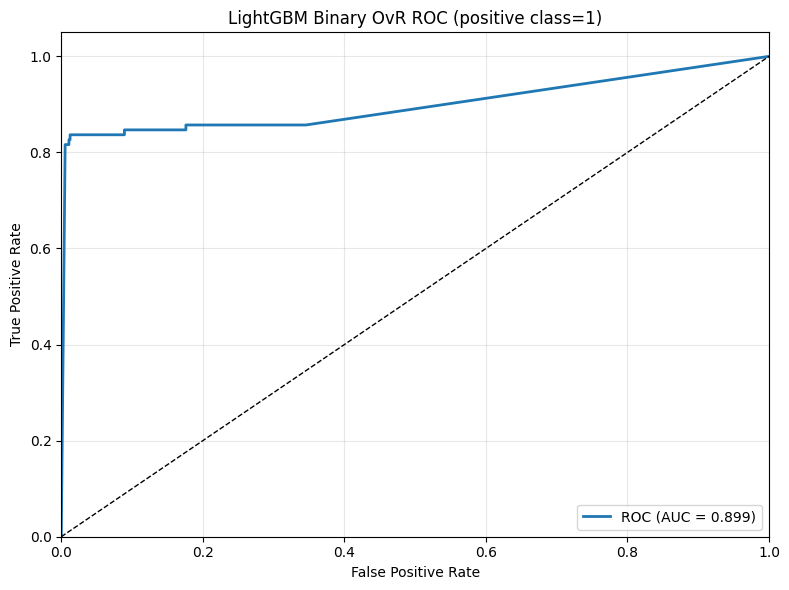

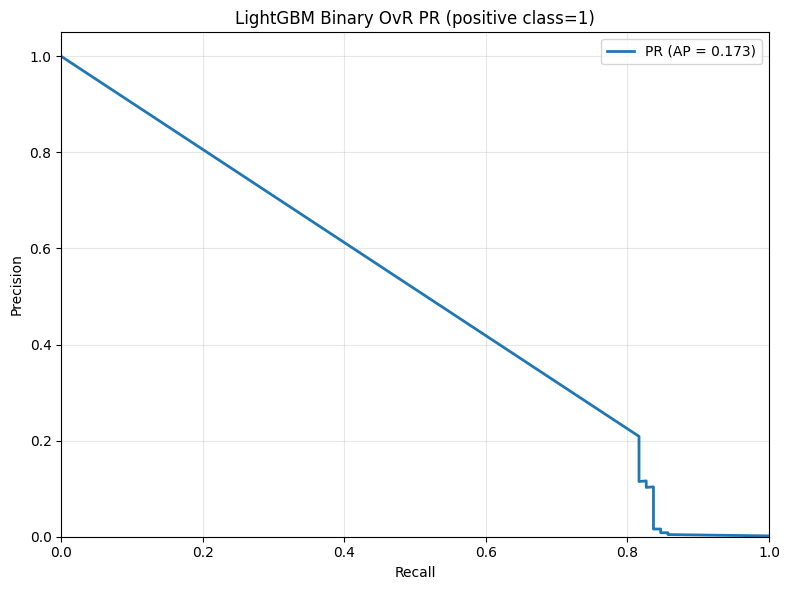


Confusion Matrix (positive class=1):
[[56466   398]
 [   18    80]]

Classification Report (binary OvR):
              precision    recall  f1-score   support

 not class 1       1.00      0.99      1.00     56864
     class 1       0.17      0.82      0.28        98

    accuracy                           0.99     56962
   macro avg       0.58      0.90      0.64     56962
weighted avg       1.00      0.99      1.00     56962



In [11]:
# Train model using best iteration from CV
# print(f"Training with best_iteration from CV: {best_iteration}")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[lgb.log_evaluation(period=10)]
)

print("✓ Model training complete!")

# Choose positive class for binary one-vs-rest evaluation
positive_class = 1
classes_lgb = np.sort(np.unique(y_train))
if positive_class not in classes_lgb:
    raise ValueError(f"positive_class={positive_class} not found in labels: {classes_lgb}")

# Predict on test set
raw_pred = lgb_model.predict(X_test)  # returns probabilities


# Build probability for the positive class from different LightGBM output shapes
if np.ndim(raw_pred) == 1:
    # Binary objective often returns probability of positive class directly
    y_lgb_pred_proba = raw_pred.astype(float)
elif np.ndim(raw_pred) == 2:
    if raw_pred.shape[1] == 1:
        y_lgb_pred_proba = raw_pred[:, 0].astype(float)
    elif raw_pred.shape[1] == 2:
        # Binary objective returning [P(class0), P(class1)]
        y_lgb_pred_proba = raw_pred[:, 1].astype(float)
    else:
        # Multiclass output; use OvR probability for selected positive class
        pos_idx = int(np.where(classes_lgb == positive_class)[0][0])
        if pos_idx >= raw_pred.shape[1]:
            raise ValueError(
                f"positive class index {pos_idx} out of bounds for prediction shape {raw_pred.shape}"
            )
        y_lgb_pred_proba = raw_pred[:, pos_idx].astype(float)
else:
    raise ValueError(f"Unexpected prediction shape: {np.shape(raw_pred)}")

# Binary true labels and predictions (positive class vs rest)
y_test_arr = np.asarray(y_test)
y_true_bin = (y_test_arr == positive_class).astype(int)
y_pred_bin = (y_lgb_pred_proba >= 0.5).astype(int)

# Accuracy
test_accuracy_lgb = accuracy_score(y_true_bin, y_pred_bin)
print(f"\nTest set accuracy (OvR, class={positive_class}): {test_accuracy_lgb:.4f}")

# F1 scores
f1_binary = f1_score(y_true_bin, y_pred_bin, average='binary')
f1_macro = f1_score(y_true_bin, y_pred_bin, average='macro')
f1_weighted = f1_score(y_true_bin, y_pred_bin, average='weighted')

print("\nF1 Scores (OvR):")
print(f"  Binary (positive class={positive_class}): {f1_binary:.4f}")
print(f"  Macro-average: {f1_macro:.4f}")
print(f"  Weighted-average: {f1_weighted:.4f}")

# Binary ROC AUC and curve
auc_lgb = roc_auc_score(y_true_bin, y_lgb_pred_proba)
fpr_lgb, tpr_lgb, _ = roc_curve(y_true_bin, y_lgb_pred_proba)
print("\nBinary ROC AUC (OvR):")
print(f"  AUC: {auc_lgb:.4f}")

# Binary AUPRC and curve
precision_lgb, recall_lgb, _ = precision_recall_curve(y_true_bin, y_lgb_pred_proba)
auprc_lgb = average_precision_score(y_true_bin, y_lgb_pred_proba)
print("\nBinary AUPRC (OvR):")
print(f"  AP: {auprc_lgb:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, lw=2, label=f"ROC (AUC = {auc_lgb:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"LightGBM Binary OvR ROC (positive class={positive_class})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_lgb, precision_lgb, lw=2, label=f"PR (AP = {auprc_lgb:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"LightGBM Binary OvR PR (positive class={positive_class})")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix and classification report (binary labels)
print("\n" + "=" * 50)
print(f"Confusion Matrix (positive class={positive_class}):")
print(confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]))

print("\nClassification Report (binary OvR):")
print(classification_report(
    y_true_bin,
    y_pred_bin,
    labels=[0, 1],
    target_names=[f"not class {positive_class}", f"class {positive_class}"],
) )

In [14]:
# Get SHAP contributions separately (pred_contrib=True returns contributions, not probabilities)
shap_pred = lgb_model.predict(X_test, pred_contrib=True)

n_samples = X_test.shape[0]
n_features = X_test.shape[1]

# Binary LightGBM: pred_contrib returns (n_samples, n_features + 1) — always 2D
# Last column is the bias term; reshape to (n_samples, 1, n_features + 1) for uniform handling
if shap_pred.ndim == 2 and shap_pred.shape[1] == n_features + 1:
    shap_contribs_reshaped = shap_pred[:, np.newaxis, :]
else:
    # Multiclass: (n_samples, n_classes * (n_features + 1)) — reshape accordingly
    n_classes = shap_pred.shape[1] // (n_features + 1)
    shap_contribs_reshaped = shap_pred.reshape(n_samples, n_classes, n_features + 1)

# Remove bias (last column) and sum |SHAP| across samples and classes
shap_values_only_lgb = shap_contribs_reshaped[:, :, :-1]
total_abs_shap_lgb = np.abs(shap_values_only_lgb).sum(axis=(0, 1))

print("✓ SHAP values computed")

# Create feature ranking dataframe
lgb_shap_feature_ranking = pd.DataFrame({
    'feature': X_test.columns,
    'total_abs_shap': total_abs_shap_lgb
}).sort_values('total_abs_shap', ascending=False).reset_index(drop=True)

print(f"Top 10 features by total |SHAP|:")
print(lgb_shap_feature_ranking.head(10).to_string(index=False))
print()

✓ SHAP values computed
Top 10 features by total |SHAP|:
feature  total_abs_shap
    V16    4.699486e+08
    V18    3.417144e+08
     V7    3.274523e+08
     V4    2.941492e+08
     V5    2.035487e+08
     V2    1.527198e+08
     V8    1.011342e+08
    V12    9.868184e+07
     V6    5.613590e+07
    V17    4.550638e+07



### Screening with |SHAP|

In [ ]:
# Train LightGBM model to compute SHAP-based feature rankings
print("Training LightGBM model and computing SHAP values for feature ranking...")
print("=" * 70)

# Reuse lgb_params, remapping the few keys that differ in the sklearn API
_sklearn_params = {k: v for k, v in lgb_params.items()
                   if k not in ("seed", "num_threads", "deterministic", "metric")}
_sklearn_params["random_state"] = lgb_params.get("seed", 42)
_sklearn_params["n_jobs"]       = lgb_params.get("num_threads", 1)
_sklearn_params["n_estimators"] = 300  # equivalent to num_boost_round

lgb_ranking_model = lgb.LGBMClassifier(**_sklearn_params)

lgb_ranking_model.fit(X, y)
print("✓ Model trained successfully")

# Compute SHAP values using LightGBM's built-in method
print("Computing SHAP values...")

# Get SHAP contributions directly from LightGBM (includes bias term as last column)
shap_contribs_lgb = lgb_ranking_model.predict(
    X,
    pred_contrib=True
)

# For binary LightGBM: shape is (n_samples, n_features + 1)
n_samples  = X.shape[0]
n_features = X.shape[1]

if shap_contribs_lgb.ndim == 2 and shap_contribs_lgb.shape[1] == n_features + 1:
    shap_contribs_reshaped = shap_contribs_lgb[:, np.newaxis, :]
else:
    n_classes = len(lgb_ranking_model.classes_)
    shap_contribs_reshaped = shap_contribs_lgb.reshape(n_samples, n_classes, n_features + 1)

# Remove bias (last column) and sum |SHAP| across samples and classes
shap_values_only_lgb = shap_contribs_reshaped[:, :, :-1]
total_abs_shap_lgb = np.abs(shap_values_only_lgb).sum(axis=(0, 1))

print("✓ SHAP values computed")

# Create feature ranking dataframe
lgb_shap_feature_ranking = pd.DataFrame({
    'feature': X.columns,
    'total_abs_shap': total_abs_shap_lgb
}).sort_values('total_abs_shap', ascending=False).reset_index(drop=True)

print(f"Top 10 features by total |SHAP|:")
print(lgb_shap_feature_ranking.head(10).to_string(index=False))
print()

# Run performance evaluation using SHAP-based rankings
print("\n" + "=" * 70)
print("Evaluating LightGBM performance with SHAP-based feature selection...")
print("=" * 70)

lgb_shap_perf_table, lgb_shap_perf_fig = evaluate_top_features_performance(
    results_df=lgb_shap_feature_ranking,
    model_class=lgb.LGBMClassifier,
    X_full_train=X_train,
    X_full_test=X_test,
    y_train=y_train,
    y_test=y_test,
    percentages=[5, 10, 25, 50, 75, 90, 100],
    ranking_col='total_abs_shap',
    model_params={**_sklearn_params, "n_estimators": 300},
    log_x=False
)

print("\n" + "=" * 70)
print("RESULTS TABLE (LightGBM SHAP-based Feature Selection):")
print("=" * 70)
print(lgb_shap_perf_table.to_string(index=False))
print("\n✓ LightGBM SHAP-based feature selection analysis complete!")

Training LightGBM model and computing SHAP values for feature ranking...
✓ Model trained successfully
Computing SHAP values...


### Bootstrap

In [12]:
X_screened_lgb = X

X_train, X_test, y_train, y_test = train_test_split(X_screened_lgb, y, test_size=0.2, random_state=42, stratify=y)

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test = lgb.Dataset(X_test, label=y_test, reference=lgb_train)

In [17]:
# lgb_boot_results = boot_multi_repeat_inference_keep_all(
#     X=X_screened_lgb,  # Use preprocessed data with one-hot encoded categoricals
#     y=y,
#     inner_variance="permutation",
#     task="binary",
#     n_bootstrap=1000,  
#     b_model=1, 
#     zero_tol=1e-8,
#     model_wrapper=lgb_wrapper,  
#     n_jobs=6,        
#     show_progress=True
# )

# print(f"\nBootstrap complete! Generated {len(lgb_boot_results)} results.")

In [ ]:
# lgb_boot_results = boot_multi_repeat_inference_keep_feature(
#     X=X_screened_lgb,
#     y=y,
#     inner_variance="permutation",
#     task="binary",
#     n_bootstrap=1000,
#     b_model=1,
#     zero_tol=1e-8,
#     model_wrapper=lgb_wrapper,
#     n_jobs=6,
#     show_progress=True
# )

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [50:34<00:00,  3.03s/it] 


In [ ]:
# # Save — concat all 1000 small DataFrames into one
# os.makedirs("shap_results", exist_ok=True)

# pd.concat(lgb_boot_results, ignore_index=True).to_parquet(
#     "shap_results/lgb_fraud_results.parquet",
#     index=False,
#     compression="zstd"
# )
# print("Saved!")

Saved!
Loaded 1000 bootstrap results


In [13]:
# Load — split back into list by bootstrap_id
df_all = pd.read_parquet("shap_results/lgb_fraud_results.parquet")
lgb_boot_results = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(lgb_boot_results)} bootstrap results")

Loaded 1000 bootstrap results


In [18]:
# lgb_mix = estimate_sample_feature_distribution(lgb_boot_results)

In [19]:
# top_df = plot_sample_top_features_overlay(
#     mix_df=lgb_mix,
#     sample_id=0,
#     class_id=None,  # or class index for multiclass
#     top_k=15,
#     rank_by="mean_abs_estimated",
#     n_grid=600,
#     xlim=(-2, 4)
# )

In [20]:
# plot_zero_inflated_kde_with_hist(
#     mix_df=lgb_mix,
#     sample_id=0,
#     feature="5102",
#     # feature="M55150_at",
#     class_id=None,  # or None for binary/regression
#     boot_results=lgb_boot_results,  # list[DataFrame] or DataFrame
#     bins=60,
#     n_grid=800
# )

In [21]:
# plot_zero_inflated_kde_with_hist(
#     mix_df=lgb_mix,
#     sample_id=0,
#     feature="4519",
#     # feature="M23197_at",
#     class_id=None,  # or None for binary/regression
#     boot_results=lgb_boot_results,  # list[DataFrame] or DataFrame
#     bins=60,
#     n_grid=800
# )

In [28]:
# lgb_feature_kde = estimate_feature_level_mixture_fast(
#     boot_results=lgb_boot_results,
#     kernel="gaussian",
#     zero_tol=1e-8
# )

In [20]:
lgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lgb_boot_results,
    # agg_col="sum_abs_shap",
    agg_col="mean_abs_shap",
    kernel="gaussian",
    bandwidth=0.2,
    zero_tol=1e-8
)

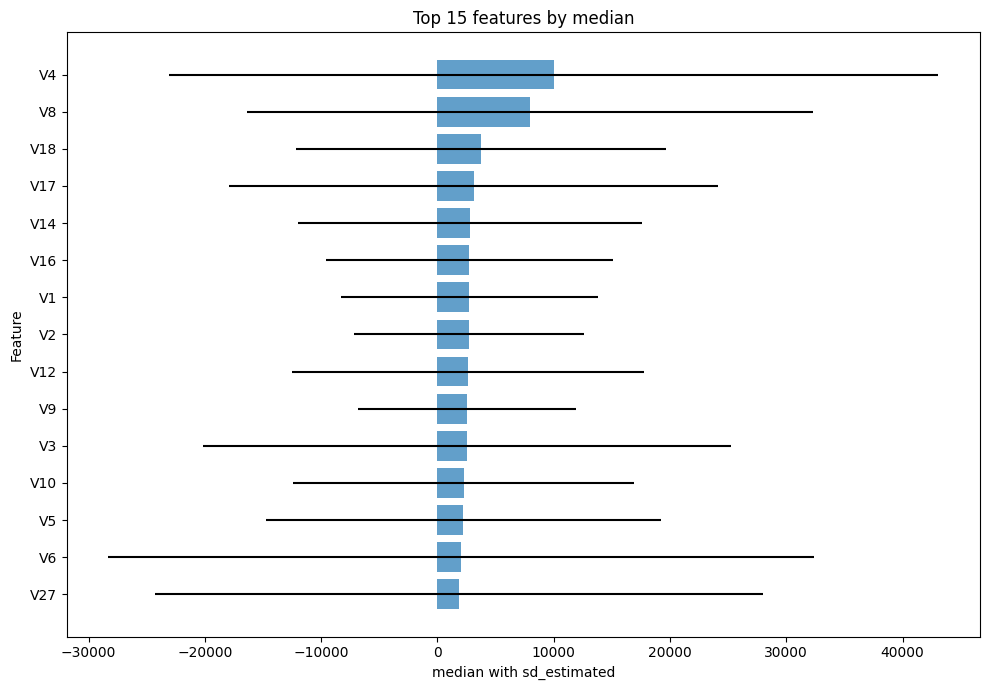

In [21]:
top_with_error = plot_top_feature_with_error(
    lgb_feature_kde,
    top_k=15,
    score_col="median",
)

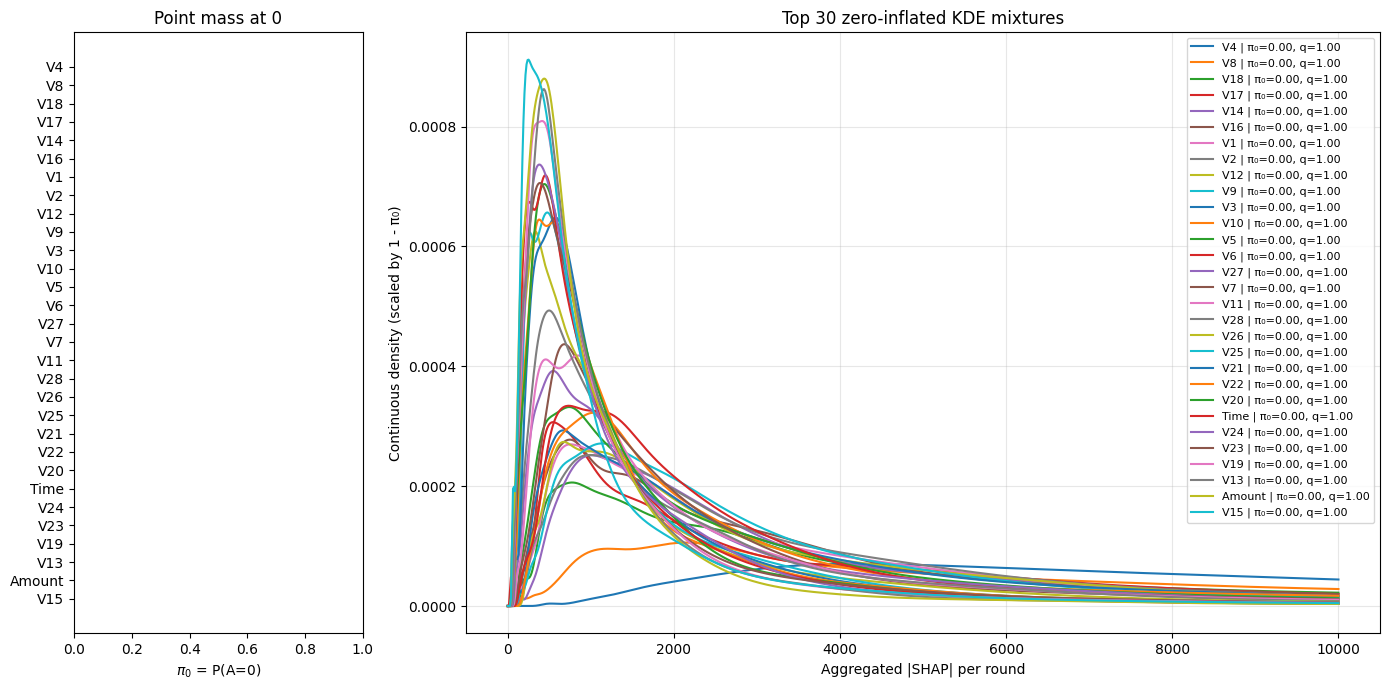

In [24]:
lgb_top = plot_top_feature_density(
    lgb_feature_kde,
    top_k=30,
    score_col="median",
    x_min = -0.5,
    log_x=False,
    x_max=1e4
)

/tmp/ipykernel_2761183/3157344887.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


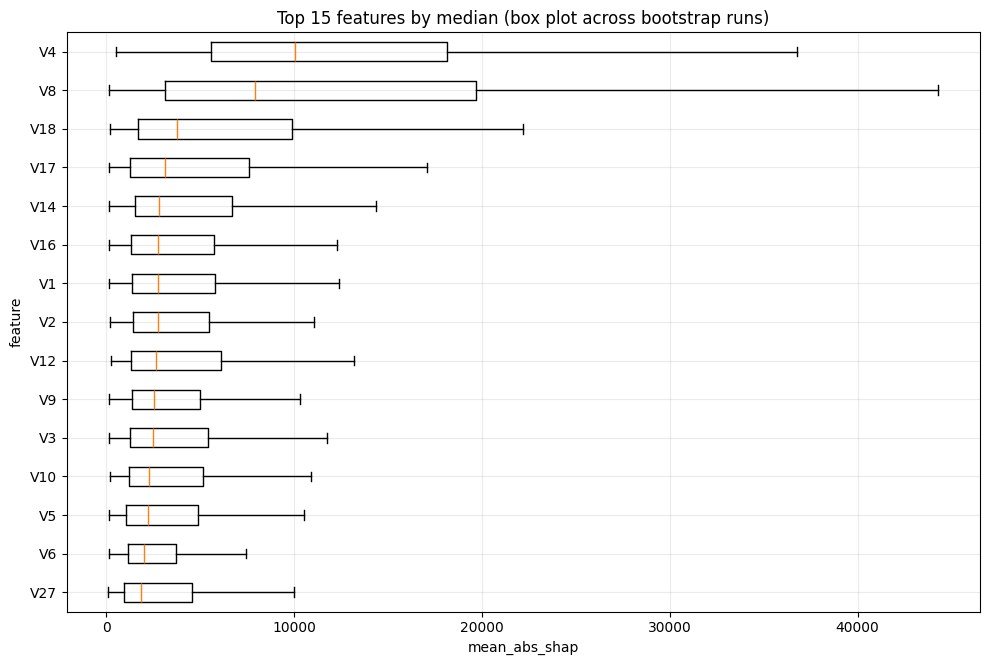

,feature,mean_abs_shap,bootstrap_id
0,V1,2070.814036,0
1,V10,7506.703819,0
2,V12,5444.236438,0
3,V14,63224.220586,0
4,V16,1055.556661,0


In [25]:
# Box plot for top features (run-level aggregated SHAP values)
top_k = 15
score_col = "median"   # ranking metric from lgb_feature_kde
agg_col = "mean_abs_shap"      # column in each element of lgb_boot_results

ranked = (
    lgb_feature_kde[["feature", score_col]]
    .dropna(subset=[score_col])
    .sort_values(score_col, ascending=False)
)

top_features = ranked["feature"].astype(str).head(top_k).tolist()

box_rows = []
for b, res in enumerate(lgb_boot_results):
    part = res.loc[:, ["feature", agg_col]].copy()
    part["feature"] = part["feature"].astype(str)
    part = part[part["feature"].isin(top_features)]
    part["bootstrap_id"] = b
    box_rows.append(part)

box_df = pd.concat(box_rows, ignore_index=True)
box_df = box_df.dropna(subset=[agg_col])

plot_data = [box_df.loc[box_df["feature"] == f, agg_col].to_numpy() for f in top_features]

plt.figure(figsize=(10, max(5, 0.45 * len(top_features))))
plt.boxplot(
    plot_data,
    labels=top_features,
    vert=False,
    showfliers=False,
)
plt.xlabel(agg_col)
plt.ylabel("feature")
plt.title(f"Top {len(top_features)} features by {score_col} (box plot across bootstrap runs)")
plt.grid(alpha=0.25)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

box_df.head()

In [20]:
# plot_feature_level_kde_with_hist(
#     feature_level_df=lgb_feature_kde,
#     boot_results=lgb_boot_results,
#     feature="V4",
#     xlim=(-0.5, 1e8)
# )

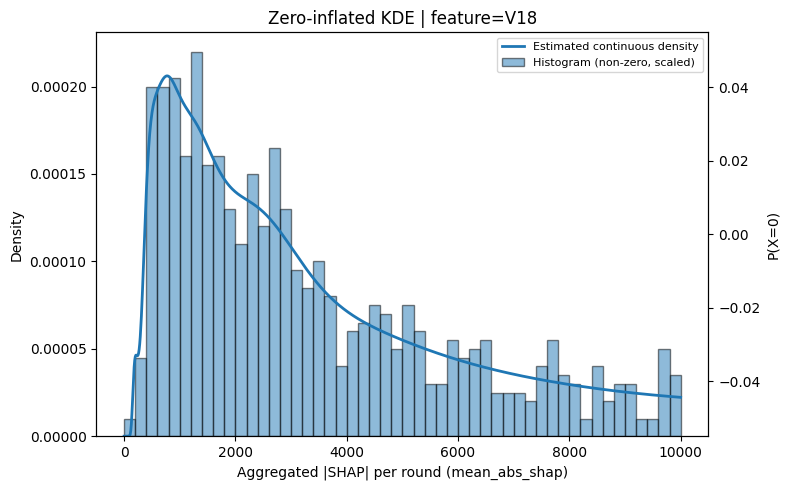

In [ ]:
plot_feature_level_kde_with_hist_preagg(
    feature_level_df=lgb_feature_kde,
    boot_results=lgb_boot_results,
    feature="V4",
    agg_col="mean_abs_shap",
    xlim=(-0.5, 1e4)
)

### Feature selection

In [53]:
# statistic you queried
stat = (lgb_feature_kde["mean_estimated"]* lgb_feature_kde["nonzero_median"]) / lgb_feature_kde["sd_estimated"]
# stat = lgb_feature_kde["nonzero_median"]*lgb_feature_kde["p_nonzero"]
stat = stat.replace([np.inf, -np.inf], np.nan).dropna()


qs = [0.01, 0.05,0.1,0.25, 0.50, 0.75, 0.8, 0.90,0.94, 0.95, 0.96,0.99]
qvals = stat.quantile(qs)
print("Quantiles of the statistic (mean^2 / sd):")
for q, val in zip(qs, qvals):
    print(f"  {q:.2%}: {val:.4f}") 

Quantiles of the statistic (mean^2 / sd):
  1.00%: 30551790.9325
  5.00%: 31470744.0363
  10.00%: 35877418.9273
  25.00%: 42529259.0560
  50.00%: 74947060.2268
  75.00%: 140634403.8759
  80.00%: 150645798.1604
  90.00%: 170804754.1964
  94.00%: 311251807.0374
  95.00%: 394722215.2546
  96.00%: 478192623.4718
  99.00%: 568865418.2022


In [54]:
q = stat.quantile(0.75)
print(f"80th percentile threshold: {q:.4f}")

# Attach statistic to feature table (index-aligned) and filter
tmp = lgb_feature_kde.copy()
tmp["stat"] = stat

features_above_q = (
    tmp.loc[tmp["stat"] > q, ["feature", "stat"]]
       .sort_values("stat", ascending=False)
       .reset_index(drop=True)
)

print(f"Number of features above 75th percentile: {len(features_above_q)}")
display(features_above_q)

# If you only want feature IDs as a Python list:
feature_list_above_q = features_above_q["feature"].astype(str).tolist()
print(feature_list_above_q)

80th percentile threshold: 140634403.8759
Number of features above 75th percentile: 8


,feature,stat
0,V8,5.870906e+08
1,V4,5.242453e+08
2,V18,2.364163e+08
3,V17,1.635146e+08
4,V1,1.544581e+08
5,V2,1.517344e+08
6,V14,1.503736e+08
7,V9,1.430538e+08


['V8', 'V4', 'V18', 'V17', 'V1', 'V2', 'V14', 'V9']


In [55]:
X_lgb = X[feature_list_above_q]

In [56]:
print("Training LightGBM model...")
X_temp, X_lgb_test, y_temp, y_lgb_test = train_test_split(X_lgb, y, test_size=0.2, random_state=123, stratify=y)
X_lgb_train, X_lgb_val, y_lgb_train, y_lgb_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=123, stratify=y_temp)  # 0.25 x 0.8 = 0.2
print(f"Training set: {X_lgb_train.shape}")
print(f"Validation set: {X_lgb_val.shape}")
print(f"Test set: {X_lgb_test.shape}")

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_lgb_train, label=y_lgb_train)
lgb_val = lgb.Dataset(X_lgb_val, label=y_lgb_val, reference=lgb_train)
lgb_test = lgb.Dataset(X_lgb_test, label=y_lgb_test, reference=lgb_train)


Training LightGBM model...
Training set: (170883, 8)
Validation set: (56962, 8)
Test set: (56962, 8)


[10]	train's average_precision: 0.672357	valid's average_precision: 0.585919
[20]	train's average_precision: 0.748569	valid's average_precision: 0.698313
[30]	train's average_precision: 0.678289	valid's average_precision: 0.625732
[40]	train's average_precision: 0.618525	valid's average_precision: 0.57928
[50]	train's average_precision: 0.287203	valid's average_precision: 0.229656
[60]	train's average_precision: 0.465331	valid's average_precision: 0.395228
[70]	train's average_precision: 0.670392	valid's average_precision: 0.612558
[80]	train's average_precision: 0.68522	valid's average_precision: 0.661901
[90]	train's average_precision: 0.557866	valid's average_precision: 0.516284
[100]	train's average_precision: 0.534127	valid's average_precision: 0.467173
[110]	train's average_precision: 0.608795	valid's average_precision: 0.539948
[120]	train's average_precision: 0.663925	valid's average_precision: 0.598803
[130]	train's average_precision: 0.687748	valid's average_precision: 0.5945

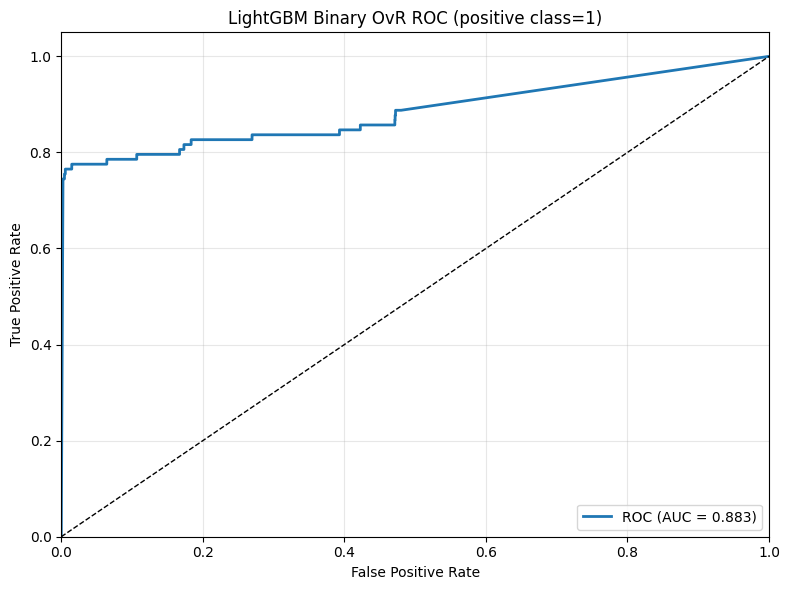

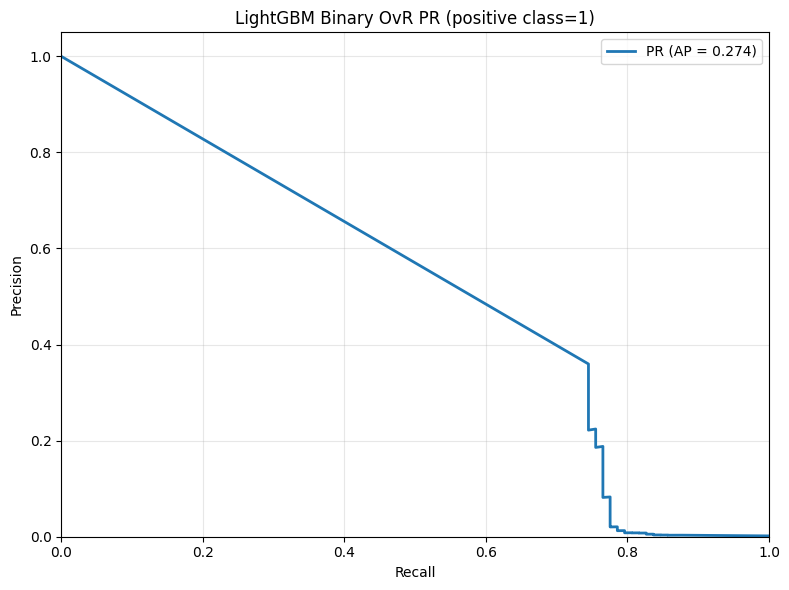


Confusion Matrix (positive class=1):
[[56656   208]
 [   25    73]]

Classification Report (binary OvR):
              precision    recall  f1-score   support

 not class 1       1.00      1.00      1.00     56864
     class 1       0.26      0.74      0.39        98

    accuracy                           1.00     56962
   macro avg       0.63      0.87      0.69     56962
weighted avg       1.00      1.00      1.00     56962



In [57]:
# Train model using best iteration from CV
# print(f"Training with best_iteration from CV: {best_iteration}")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[lgb.log_evaluation(period=10)]
)

print("✓ Model training complete!")

# Choose positive class for binary one-vs-rest evaluation
positive_class = 1
classes_lgb = np.sort(np.unique(y_lgb_train))
if positive_class not in classes_lgb:
    raise ValueError(f"positive_class={positive_class} not found in labels: {classes_lgb}")

# Predict on test set
raw_pred = lgb_model.predict(X_lgb_test)  # returns probabilities


# Build probability for the positive class from different LightGBM output shapes
if np.ndim(raw_pred) == 1:
    # Binary objective often returns probability of positive class directly
    y_lgb_pred_proba = raw_pred.astype(float)
elif np.ndim(raw_pred) == 2:
    if raw_pred.shape[1] == 1:
        y_lgb_pred_proba = raw_pred[:, 0].astype(float)
    elif raw_pred.shape[1] == 2:
        # Binary objective returning [P(class0), P(class1)]
        y_lgb_pred_proba = raw_pred[:, 1].astype(float)
    else:
        # Multiclass output; use OvR probability for selected positive class
        pos_idx = int(np.where(classes_lgb == positive_class)[0][0])
        if pos_idx >= raw_pred.shape[1]:
            raise ValueError(
                f"positive class index {pos_idx} out of bounds for prediction shape {raw_pred.shape}"
            )
        y_lgb_pred_proba = raw_pred[:, pos_idx].astype(float)
else:
    raise ValueError(f"Unexpected prediction shape: {np.shape(raw_pred)}")

# Binary true labels and predictions (positive class vs rest)
y_test_arr = np.asarray(y_lgb_test)
y_true_bin = (y_test_arr == positive_class).astype(int)
y_pred_bin = (y_lgb_pred_proba >= 0.5).astype(int)

# Accuracy
test_accuracy_lgb = accuracy_score(y_true_bin, y_pred_bin)
print(f"\nTest set accuracy (OvR, class={positive_class}): {test_accuracy_lgb:.4f}")

# F1 scores
f1_binary = f1_score(y_true_bin, y_pred_bin, average='binary')
f1_macro = f1_score(y_true_bin, y_pred_bin, average='macro')
f1_weighted = f1_score(y_true_bin, y_pred_bin, average='weighted')

print("\nF1 Scores (OvR):")
print(f"  Binary (positive class={positive_class}): {f1_binary:.4f}")
print(f"  Macro-average: {f1_macro:.4f}")
print(f"  Weighted-average: {f1_weighted:.4f}")

# Binary ROC AUC and curve
auc_lgb = roc_auc_score(y_true_bin, y_lgb_pred_proba)
fpr_lgb, tpr_lgb, _ = roc_curve(y_true_bin, y_lgb_pred_proba)
print("\nBinary ROC AUC (OvR):")
print(f"  AUC: {auc_lgb:.4f}")

# Binary AUPRC and curve
precision_lgb, recall_lgb, _ = precision_recall_curve(y_true_bin, y_lgb_pred_proba)
auprc_lgb = average_precision_score(y_true_bin, y_lgb_pred_proba)
print("\nBinary AUPRC (OvR):")
print(f"  AP: {auprc_lgb:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, lw=2, label=f"ROC (AUC = {auc_lgb:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"LightGBM Binary OvR ROC (positive class={positive_class})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_lgb, precision_lgb, lw=2, label=f"PR (AP = {auprc_lgb:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"LightGBM Binary OvR PR (positive class={positive_class})")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix and classification report (binary labels)
print("\n" + "=" * 50)
print(f"Confusion Matrix (positive class={positive_class}):")
print(confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]))

print("\nClassification Report (binary OvR):")
print(classification_report(
    y_true_bin,
    y_pred_bin,
    labels=[0, 1],
    target_names=[f"not class {positive_class}", f"class {positive_class}"],
) )

### Compare with other methods

In [43]:
feature_shap = lgb_shap_feature_ranking.iloc[:8]['feature'].tolist()
X_lgb = X[feature_shap]

In [44]:
print("Training LightGBM model...")
X_temp, X_lgb_test, y_temp, y_lgb_test = train_test_split(X_lgb, y, test_size=0.2, random_state=123, stratify=y)
X_lgb_train, X_lgb_val, y_lgb_train, y_lgb_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=123, stratify=y_temp)  # 0.25 x 0.8 = 0.2
print(f"Training set: {X_lgb_train.shape}")
print(f"Validation set: {X_lgb_val.shape}")
print(f"Test set: {X_lgb_test.shape}")

# Create LightGBM datasets
lgb_train = lgb.Dataset(X_lgb_train, label=y_lgb_train)
lgb_val = lgb.Dataset(X_lgb_val, label=y_lgb_val, reference=lgb_train)
lgb_test = lgb.Dataset(X_lgb_test, label=y_lgb_test, reference=lgb_train)


Training LightGBM model...
Training set: (170883, 8)
Validation set: (56962, 8)
Test set: (56962, 8)


[10]	train's average_precision: 0.684775	valid's average_precision: 0.637258
[20]	train's average_precision: 0.648936	valid's average_precision: 0.605494
[30]	train's average_precision: 0.681217	valid's average_precision: 0.646138
[40]	train's average_precision: 0.68581	valid's average_precision: 0.657908
[50]	train's average_precision: 0.646773	valid's average_precision: 0.610672
[60]	train's average_precision: 0.653464	valid's average_precision: 0.608515
[70]	train's average_precision: 0.62881	valid's average_precision: 0.584921
[80]	train's average_precision: 0.536919	valid's average_precision: 0.533828
[90]	train's average_precision: 0.621663	valid's average_precision: 0.629087
[100]	train's average_precision: 0.601589	valid's average_precision: 0.634846
[110]	train's average_precision: 0.654982	valid's average_precision: 0.664934
[120]	train's average_precision: 0.61513	valid's average_precision: 0.662162
[130]	train's average_precision: 0.654511	valid's average_precision: 0.67758

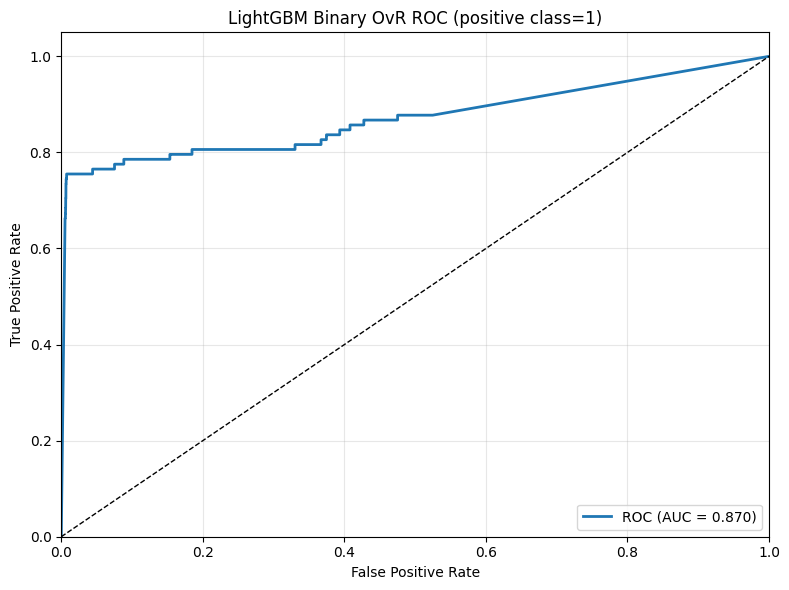

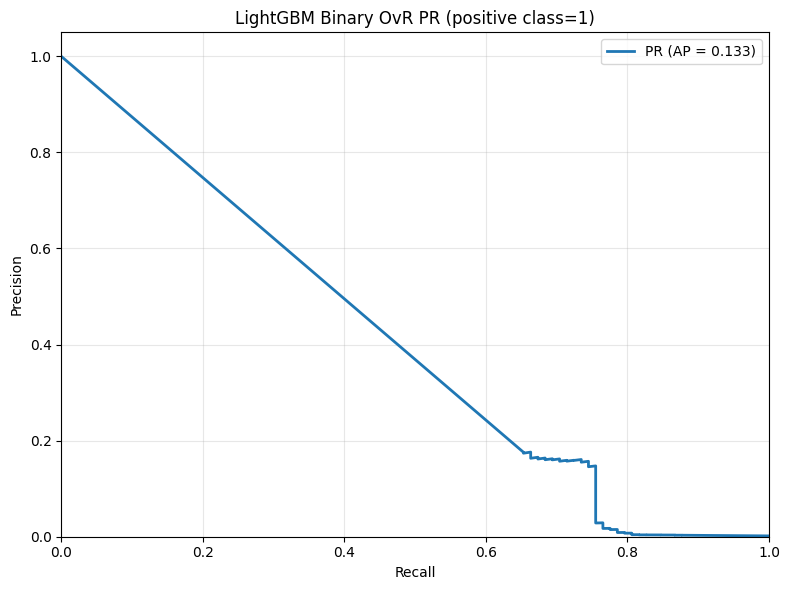


Confusion Matrix (positive class=1):
[[56490   374]
 [   28    70]]

Classification Report (binary OvR):
              precision    recall  f1-score   support

 not class 1       1.00      0.99      1.00     56864
     class 1       0.16      0.71      0.26        98

    accuracy                           0.99     56962
   macro avg       0.58      0.85      0.63     56962
weighted avg       1.00      0.99      1.00     56962



In [45]:
# Train model using best iteration from CV
# print(f"Training with best_iteration from CV: {best_iteration}")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[lgb.log_evaluation(period=10)]
)

print("✓ Model training complete!")

# Choose positive class for binary one-vs-rest evaluation
positive_class = 1
classes_lgb = np.sort(np.unique(y_lgb_train))
if positive_class not in classes_lgb:
    raise ValueError(f"positive_class={positive_class} not found in labels: {classes_lgb}")

# Predict on test set
raw_pred = lgb_model.predict(X_lgb_test)  # returns probabilities


# Build probability for the positive class from different LightGBM output shapes
if np.ndim(raw_pred) == 1:
    # Binary objective often returns probability of positive class directly
    y_lgb_pred_proba = raw_pred.astype(float)
elif np.ndim(raw_pred) == 2:
    if raw_pred.shape[1] == 1:
        y_lgb_pred_proba = raw_pred[:, 0].astype(float)
    elif raw_pred.shape[1] == 2:
        # Binary objective returning [P(class0), P(class1)]
        y_lgb_pred_proba = raw_pred[:, 1].astype(float)
    else:
        # Multiclass output; use OvR probability for selected positive class
        pos_idx = int(np.where(classes_lgb == positive_class)[0][0])
        if pos_idx >= raw_pred.shape[1]:
            raise ValueError(
                f"positive class index {pos_idx} out of bounds for prediction shape {raw_pred.shape}"
            )
        y_lgb_pred_proba = raw_pred[:, pos_idx].astype(float)
else:
    raise ValueError(f"Unexpected prediction shape: {np.shape(raw_pred)}")

# Binary true labels and predictions (positive class vs rest)
y_test_arr = np.asarray(y_lgb_test)
y_true_bin = (y_test_arr == positive_class).astype(int)
y_pred_bin = (y_lgb_pred_proba >= 0.5).astype(int)

# Accuracy
test_accuracy_lgb = accuracy_score(y_true_bin, y_pred_bin)
print(f"\nTest set accuracy (OvR, class={positive_class}): {test_accuracy_lgb:.4f}")

# F1 scores
f1_binary = f1_score(y_true_bin, y_pred_bin, average='binary')
f1_macro = f1_score(y_true_bin, y_pred_bin, average='macro')
f1_weighted = f1_score(y_true_bin, y_pred_bin, average='weighted')

print("\nF1 Scores (OvR):")
print(f"  Binary (positive class={positive_class}): {f1_binary:.4f}")
print(f"  Macro-average: {f1_macro:.4f}")
print(f"  Weighted-average: {f1_weighted:.4f}")

# Binary ROC AUC and curve
auc_lgb = roc_auc_score(y_true_bin, y_lgb_pred_proba)
fpr_lgb, tpr_lgb, _ = roc_curve(y_true_bin, y_lgb_pred_proba)
print("\nBinary ROC AUC (OvR):")
print(f"  AUC: {auc_lgb:.4f}")

# Binary AUPRC and curve
precision_lgb, recall_lgb, _ = precision_recall_curve(y_true_bin, y_lgb_pred_proba)
auprc_lgb = average_precision_score(y_true_bin, y_lgb_pred_proba)
print("\nBinary AUPRC (OvR):")
print(f"  AP: {auprc_lgb:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, lw=2, label=f"ROC (AUC = {auc_lgb:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"LightGBM Binary OvR ROC (positive class={positive_class})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_lgb, precision_lgb, lw=2, label=f"PR (AP = {auprc_lgb:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"LightGBM Binary OvR PR (positive class={positive_class})")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix and classification report (binary labels)
print("\n" + "=" * 50)
print(f"Confusion Matrix (positive class={positive_class}):")
print(confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]))

print("\nClassification Report (binary OvR):")
print(classification_report(
    y_true_bin,
    y_pred_bin,
    labels=[0, 1],
    target_names=[f"not class {positive_class}", f"class {positive_class}"],
) )

In [167]:
# # LightGBM with Information Gain Feature Selection
# # Compute Information Gain (Mutual Information) scores
# print("Computing Information Gain scores for all features...")
# ig_scores = mutual_info_classif(X_processed, y, random_state=42)
# # Create feature ranking
# ig_feature_ranking_lgb = pd.DataFrame({
#     'feature': X_processed.columns,
#     'ig_score': ig_scores
# }).sort_values('ig_score', ascending=False).reset_index(drop=True)

# print(f"\nTop 10 features by Information Gain:")
# print(ig_feature_ranking_lgb.head(10))

# # Evaluate LightGBM performance with different numbers of top IG features
# print("\nEvaluating LightGBM with IG-selected features...")

# # Information Gain
# print("\n" + "=" * 70)
# print("Evaluating with Information Gain feature selection...")

# eval_params = {
#     'max_iter': 1000,
#     'solver': 'lbfgs',
#     'random_state': 42,
#     'n_jobs': 1
# }
# percentages = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]


# ig_perf_table_lr, ig_perf_fig_lr = evaluate_top_features_performance(
#     results_df=ig_feature_ranking_lgb,
#     model_class=LogisticRegression,
#     X_full_train=X_train, X_full_test=X_test,
#     y_train=y_train, y_test=y_test,
#     percentages=percentages, ranking_col='ig_score',
#     model_params=eval_params, log_x=True
# )

# print("\n✓ LightGBM IG-based feature selection analysis complete!")

In [ ]:
# # Feature Selection using LightGBM Feature Importance (Gain)

# print("Training LightGBM to compute feature importance...")

# # Prepare data for LightGBM


# # Create LightGBM datasets
# lgb_train_fi = lgb.Dataset(X_lgb_train, label=y_lgb_train)
# lgb_test_fi = lgb.Dataset(X_lgb_test, label=y_lgb_test, reference=lgb_train_fi)

# # Train LightGBM model to get feature importance
# lgb_model_fi = lgb.train(
#     lgb_params,
#     lgb_train_fi,
#     num_boost_round=100,
#     valid_sets=[lgb_train_fi, lgb_test_fi],
#     valid_names=['train', 'test']
# )

# # Get feature importance (using gain)
# feature_importance_gain = lgb_model_fi.feature_importance(importance_type='gain')
# feature_importance_split = lgb_model_fi.feature_importance(importance_type='split')

# # Create feature importance ranking
# fi_gain_ranking = pd.DataFrame({
#     'feature': X_grouped.columns,
#     'importance_gain': feature_importance_gain,
#     'importance_split': feature_importance_split
# }).sort_values('importance_gain', ascending=False).reset_index(drop=True)

# print(f"\nTop 20 features by LightGBM Feature Importance (Gain):")
# print(fi_gain_ranking.head(20))

# # Select top features based on feature importance
# top_k_fi = 50  # Select top 50 features
# selected_features_fi = fi_gain_ranking.head(top_k_fi)['feature'].tolist()

# print(f"\nSelected {len(selected_features_fi)} features based on feature importance")

# # Evaluate with different numbers of top features
# print("\nEvaluating LightGBM with different numbers of top features...")
# percentages_fi = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100]
# fi_results = []

# for pct in percentages_fi:
#     n_features = max(1, int(len(X_grouped.columns) * pct / 100))
#     top_features = fi_gain_ranking.head(n_features)['feature'].tolist()
    
#     # Select features
#     X_fi_train = X_lgb_train[top_features]
#     X_fi_test = X_lgb_test[top_features]
    
#     # Create datasets
#     dtrain_fi = lgb.Dataset(X_fi_train, label=y_lgb_train)
#     dtest_fi = lgb.Dataset(X_fi_test, label=y_lgb_test, reference=dtrain_fi)
    
#     # Train model
#     model_fi = lgb.train(
#         lgb_params,
#         dtrain_fi,
#         num_boost_round=100,
#         valid_sets=[dtest_fi],
#         valid_names=['test'],
#     )
    
#     # Evaluate
#     y_pred_proba = model_fi.predict(X_fi_test)
#     y_pred = np.argmax(y_pred_proba, axis=1)
    
#     accuracy = accuracy_score(y_lgb_test, y_pred)
    
#     fi_results.append({
#         'percentage': pct,
#         'n_features': n_features,
#         'accuracy': accuracy
#     })
    
#     print(f"  {pct}% ({n_features} features): Accuracy = {accuracy:.4f}")

# fi_perf_table = pd.DataFrame(fi_results)

# print("\nRESULTS TABLE (LightGBM Feature Importance-based Selection):")
# print(fi_perf_table.to_string(index=False))

# # Visualize results
# plt.figure(figsize=(10, 6))
# plt.plot(fi_perf_table['n_features'], fi_perf_table['accuracy'], marker='o', linewidth=2)
# plt.xlabel('Number of Features', fontsize=12)
# plt.ylabel('Test Accuracy', fontsize=12)
# plt.title('LightGBM Performance: Feature Importance-based Selection', fontsize=14)
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

# print("\n✓ LightGBM Feature Importance-based feature selection analysis complete!")

## XGBoost

In [102]:
seed = 42

xgb_params = {
        'objective': 'multi:softprob', # for multi-class classification
        'num_class': 3, # number of classes for multi-class classification
        'seed':seed, # random seed
        'eval_metric': 'mlogloss',  # multi-class logloss
        'eta': 0.5, # learning rate
        'max_depth': 10,
        'min_child_weight': 0.2,
        'subsample': 0.8, 
        'colsample_bytree': 0.6,
            # Moderate regularization
        "lambda": 3.0,
        "alpha": 0.5,
       }

binary_params = {
    'objective': 'binary:logistic', # for binary classification
    'seed':seed, # random seed
    'eval_metric': 'logloss',  # binary logloss
    'eta': 0.5, # learning rate
    'max_depth': 10,
    'min_child_weight': 0.2,
    'subsample': 0.8, 
    'colsample_bytree': 0.6,
}

In [115]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=99, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=99, stratify=y_temp)  # 0.25 x 0.8 = 0.2

dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dval   = xgb.DMatrix(X_val,   label=y_val,   enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)

[0]	train-logloss:0.02041	valid-logloss:0.01656
[10]	train-logloss:0.00131	valid-logloss:0.00715
[20]	train-logloss:0.00025	valid-logloss:0.00678
[30]	train-logloss:0.00008	valid-logloss:0.00624
[40]	train-logloss:0.00004	valid-logloss:0.00632
[50]	train-logloss:0.00003	valid-logloss:0.00641
[60]	train-logloss:0.00002	valid-logloss:0.00646
[70]	train-logloss:0.00002	valid-logloss:0.00648
[80]	train-logloss:0.00002	valid-logloss:0.00648
[90]	train-logloss:0.00002	valid-logloss:0.00653
[100]	train-logloss:0.00001	valid-logloss:0.00652
[110]	train-logloss:0.00001	valid-logloss:0.00657
[120]	train-logloss:0.00001	valid-logloss:0.00658
[130]	train-logloss:0.00001	valid-logloss:0.00658
[140]	train-logloss:0.00001	valid-logloss:0.00658
[150]	train-logloss:0.00001	valid-logloss:0.00661
[160]	train-logloss:0.00001	valid-logloss:0.00662
[170]	train-logloss:0.00001	valid-logloss:0.00662
[180]	train-logloss:0.00001	valid-logloss:0.00661
[190]	train-logloss:0.00001	valid-logloss:0.00660
[199]	train

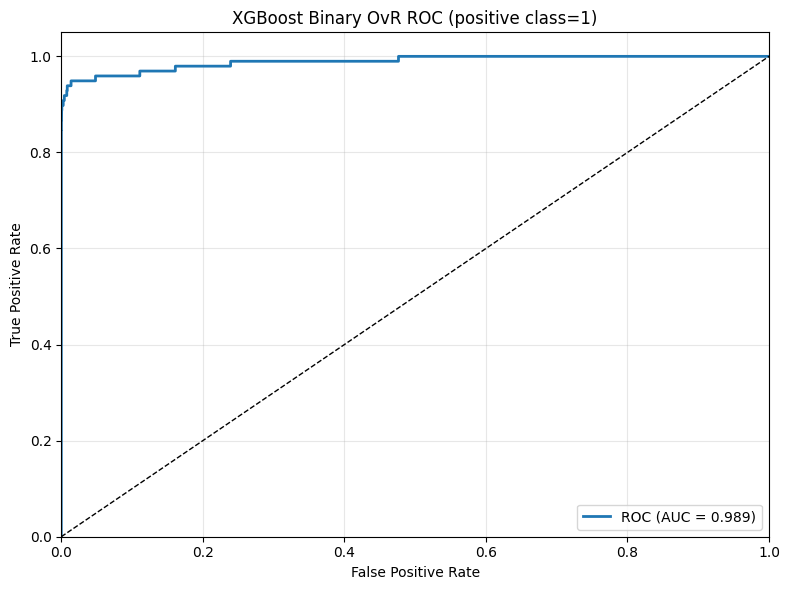

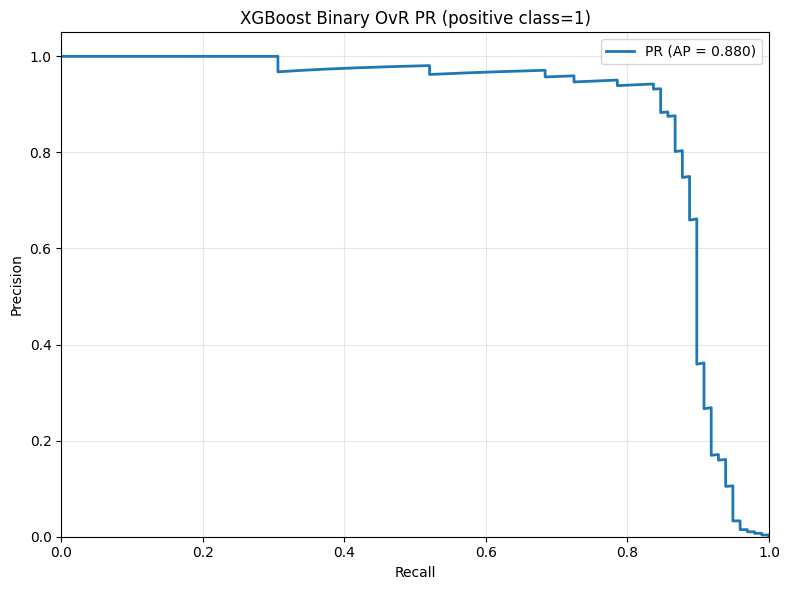


Confusion Matrix (positive class=1):
[[56859     5]
 [   21    77]]

Classification Report (binary OvR):
              precision    recall  f1-score   support

 not class 1       1.00      1.00      1.00     56864
     class 1       0.94      0.79      0.86        98

    accuracy                           1.00     56962
   macro avg       0.97      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [116]:
# Train model using best iteration from CV
# print(f"Training with best_iteration from CV: {best_iteration}")
xgb_model = xgb.train(
    binary_params,                      # or xgb_params if you are doing multiclass
    dtrain,
    num_boost_round=200,
    evals=[(dtrain, "train"), (dval, "valid")],
    verbose_eval=10
)

print("✓ Model training complete!")

# Choose positive class for binary one-vs-rest evaluation
positive_class = 1
classes_xgb = np.sort(np.unique(y_train))
if positive_class not in classes_xgb:
    raise ValueError(f"positive_class={positive_class} not found in labels: {classes_xgb}")

# Predict on test set
# strict_shape=True makes output handling more consistent across objectives
raw_pred = xgb_model.predict(dtest, strict_shape=True)

# Build probability for the positive class from different XGBoost output shapes
raw_pred = np.asarray(raw_pred)

if raw_pred.ndim == 1:
    # Binary objective may return probability of positive class directly
    y_xgb_pred_proba = raw_pred.astype(float)
elif raw_pred.ndim == 2:
    if raw_pred.shape[1] == 1:
        y_xgb_pred_proba = raw_pred[:, 0].astype(float)
    elif raw_pred.shape[1] == 2:
        # Binary output returning [P(class0), P(class1)]
        y_xgb_pred_proba = raw_pred[:, 1].astype(float)
    else:
        # Multiclass output; use OvR probability for selected positive class
        pos_idx = int(np.where(classes_xgb == positive_class)[0][0])
        if pos_idx >= raw_pred.shape[1]:
            raise ValueError(
                f"positive class index {pos_idx} out of bounds for prediction shape {raw_pred.shape}"
            )
        y_xgb_pred_proba = raw_pred[:, pos_idx].astype(float)
elif raw_pred.ndim == 3:
    # strict_shape=True can produce (n_samples, n_groups, n_classes_or_1)
    # for binary: n_classes_or_1 is often 1
    if raw_pred.shape[2] == 1:
        y_xgb_pred_proba = raw_pred[:, 0, 0].astype(float)
    else:
        pos_idx = int(np.where(classes_xgb == positive_class)[0][0])
        if pos_idx >= raw_pred.shape[2]:
            raise ValueError(
                f"positive class index {pos_idx} out of bounds for prediction shape {raw_pred.shape}"
            )
        y_xgb_pred_proba = raw_pred[:, 0, pos_idx].astype(float)
else:
    raise ValueError(f"Unexpected prediction shape: {raw_pred.shape}")

# Binary true labels and predictions (positive class vs rest)
y_test_arr = np.asarray(y_test)
y_true_bin = (y_test_arr == positive_class).astype(int)
y_pred_bin = (y_xgb_pred_proba >= 0.5).astype(int)

# Accuracy
test_accuracy_xgb = accuracy_score(y_true_bin, y_pred_bin)
print(f"\nTest set accuracy (OvR, class={positive_class}): {test_accuracy_xgb:.4f}")

# F1 scores
f1_binary = f1_score(y_true_bin, y_pred_bin, average="binary")
f1_macro = f1_score(y_true_bin, y_pred_bin, average="macro")
f1_weighted = f1_score(y_true_bin, y_pred_bin, average="weighted")

print("\nF1 Scores (OvR):")
print(f"  Binary (positive class={positive_class}): {f1_binary:.4f}")
print(f"  Macro-average: {f1_macro:.4f}")
print(f"  Weighted-average: {f1_weighted:.4f}")

# Binary ROC AUC and curve
auc_xgb = roc_auc_score(y_true_bin, y_xgb_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_true_bin, y_xgb_pred_proba)
print("\nBinary ROC AUC (OvR):")
print(f"  AUC: {auc_xgb:.4f}")

# Binary AUPRC and curve
precision_xgb, recall_xgb, _ = precision_recall_curve(y_true_bin, y_xgb_pred_proba)
auprc_xgb = average_precision_score(y_true_bin, y_xgb_pred_proba)
print("\nBinary AUPRC (OvR):")
print(f"  AP: {auprc_xgb:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, lw=2, label=f"ROC (AUC = {auc_xgb:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"XGBoost Binary OvR ROC (positive class={positive_class})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, lw=2, label=f"PR (AP = {auprc_xgb:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"XGBoost Binary OvR PR (positive class={positive_class})")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix and classification report (binary labels)
print("\n" + "=" * 50)
print(f"Confusion Matrix (positive class={positive_class}):")
print(confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]))

print("\nClassification Report (binary OvR):")
print(classification_report(
    y_true_bin,
    y_pred_bin,
    labels=[0, 1],
    target_names=[f"not class {positive_class}", f"class {positive_class}"],
))

### Screening with |SHAP|

Training XGBoost model and computing SHAP values for feature ranking...
✓ Model trained successfully
Computing SHAP values on the training split...
✓ SHAP values computed

Top 20 features by total |SHAP|:
feature  total_abs_shap
    V14   275907.437500
     V4   257072.625000
    V17   173946.453125
    V12   113158.953125
    V10   106328.000000
    V18    96488.289062
 Amount    93409.226562
     V8    93033.109375
    V19    79418.992188
    V13    62747.562500
    V16    61932.437500
     V7    57087.945312
     V3    54776.429688
    V26    53463.648438
    V11    52935.332031
   Time    48412.148438
     V5    44198.539062
     V6    42078.878906
    V20    41144.152344
    V25    39293.363281


Evaluating XGBoost performance with SHAP-based feature selection...
✓ 1% (1 features): Acc=0.9983, F1=0.4996, AUC(macro)=0.0516
✓ 10% (3 features): Acc=0.9986, F1=0.8208, AUC(macro)=0.9451
✓ 50% (15 features): Acc=0.9995, F1=0.9156, AUC(macro)=0.9876
✓ 100% (30 features): Acc=0.9996, F1=0

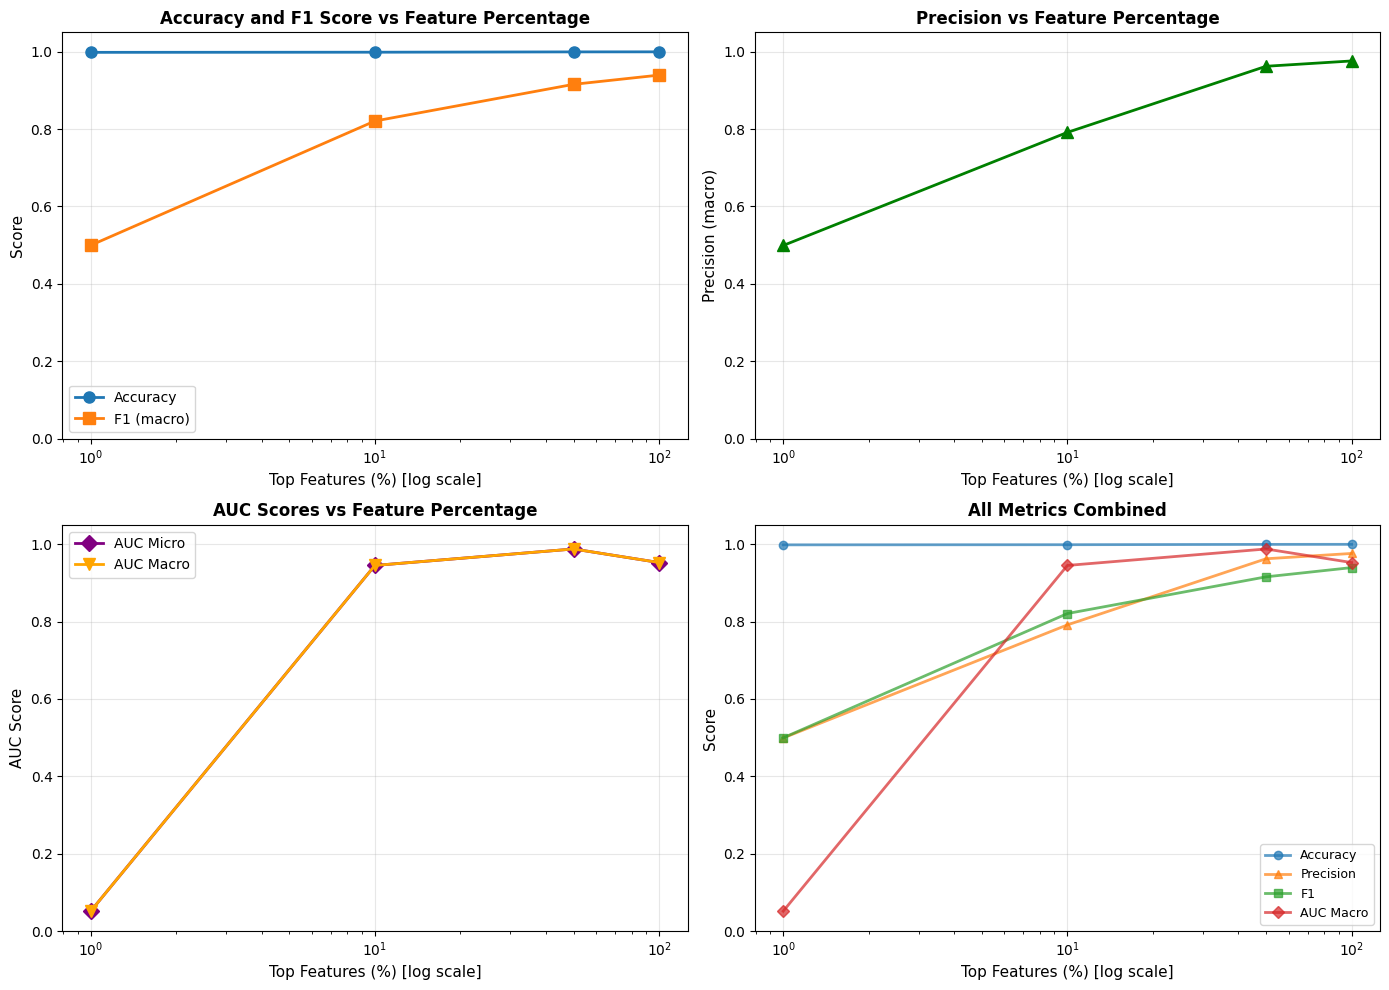


RESULTS TABLE (SHAP-based Feature Selection):
 Percentage  N_Features  Accuracy  Precision (macro)  F1 (macro)  AUC Micro  AUC Macro
          1           1  0.998280           0.499140    0.499570   0.051585   0.051585
         10           3  0.998631           0.791420    0.820758   0.945065   0.945065
         50          15  0.999473           0.962289    0.915598   0.987605   0.987605
        100          30  0.999614           0.976032    0.939464   0.952538   0.952538

✓ SHAP-based feature selection analysis complete!


In [117]:
# Train XGBoost model to compute SHAP-based feature rankings without leakage
print("Training XGBoost model and computing SHAP values for feature ranking...")
print("=" * 70)

classes_xgb = np.sort(np.unique(y_train))
if len(classes_xgb) != 2:
    raise ValueError(f"This ranking cell is configured for binary XGBoost, got classes {classes_xgb}")

xgb_ranking_model = xgb.XGBClassifier(
    **binary_params,
    enable_categorical=True,
 )

# Fit on the training split only to avoid leakage
xgb_ranking_model.fit(X_train, y_train)
print("✓ Model trained successfully")

# Compute SHAP values on the training split only
print("Computing SHAP values on the training split...")
dtrain_rank = xgb.DMatrix(X_train, enable_categorical=True)

# Get SHAP contributions directly from XGBoost (includes bias term as last column)
shap_contribs = xgb_ranking_model.get_booster().predict(
    dtrain_rank,
    pred_contribs=True,
    strict_shape=True,
 )

# Binary XGBoost can return either:
#   (n_samples, n_features + 1)
# or with strict_shape:
#   (n_samples, 1, n_features + 1)
shap_contribs = np.asarray(shap_contribs)
if shap_contribs.ndim == 3:
    shap_values_only = shap_contribs[:, 0, :-1]
elif shap_contribs.ndim == 2:
    shap_values_only = shap_contribs[:, :-1]
else:
    raise ValueError(f"Unexpected SHAP contribution shape for binary XGBoost: {shap_contribs.shape}")

total_abs_shap = np.abs(shap_values_only).sum(axis=0)
print("✓ SHAP values computed")

# Create feature ranking dataframe
shap_feature_ranking = pd.DataFrame({
    "feature": X_train.columns,
    "total_abs_shap": total_abs_shap,
}).sort_values("total_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop 20 features by total |SHAP|:")
print(shap_feature_ranking.head(20).to_string(index=False))
print()

# Run performance evaluation using held-out test data
print("\n" + "=" * 70)
print("Evaluating XGBoost performance with SHAP-based feature selection...")
print("=" * 70)

shap_perf_table, shap_perf_fig = evaluate_top_features_performance(
    results_df=shap_feature_ranking,
    model_class=xgb.XGBClassifier,
    X_full_train=X_train,
    X_full_test=X_test,
    y_train=y_train,
    y_test=y_test,
    percentages=[ 1, 10, 50, 100],
    ranking_col="total_abs_shap",
    model_params=binary_params,
    log_x=True,
 )

print("\n" + "=" * 70)
print("RESULTS TABLE (SHAP-based Feature Selection):")
print("=" * 70)
print(shap_perf_table.to_string(index=False))
print("\n✓ SHAP-based feature selection analysis complete!")

In [13]:
X_xgb = X

### Bootstrap

In [87]:
xgb_wrapper = create_model_wrapper(
    "xgboost",
    params=xgb_params,
    num_boost_round=150
)

In [ ]:
# xgb_boot_results = boot_multi_repeat_inference_keep_feature(
#     X=X_xgb,  # Use preprocessed data with one-hot encoded categoricals
#     y=y,
#     inner_variance="permutation",
#     task="binary",
#     n_bootstrap=1000,  # Fewer bootstraps for speed with MLP
#     b_model=1,       # Fewer models per bootstrap
#     zero_tol=1e-8,
#     params=binary_params,
#     n_jobs=6,       
#     show_progress=True
# )

# print(f"\nBootstrap complete! Generated {len(xgb_boot_results)} results.")

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [3:03:02<00:00, 10.98s/it] 


Bootstrap complete! Generated 1000 results.


In [ ]:
# # Save — concat all 1000 small DataFrames into one
# os.makedirs("shap_results", exist_ok=True)

# pd.concat(xgb_boot_results, ignore_index=True).to_parquet(
#     "shap_results/xgb_fraud_results.parquet",
#     index=False,
#     compression="zstd"
# )
# print("Saved!")

Saved!


In [29]:
# Load — split back into list by bootstrap_id
df_all = pd.read_parquet("shap_results/xgb_fraud_results.parquet")
xgb_boot_results = [grp for _, grp in df_all.groupby("bootstrap_id", sort=True)]
print(f"Loaded {len(xgb_boot_results)} bootstrap results")

Loaded 1000 bootstrap results


In [16]:
# xgb_mix = estimate_sample_feature_distribution(xgb_boot_results)

In [17]:
# top_df = plot_sample_top_features_overlay(
#     mix_df=xgb_mix,
#     sample_id=0,
#     class_id=None,  # or class index for multiclass
#     top_k=15,
#     rank_by="mean_abs_estimated",
#     n_grid=600,
#     xlim=(-4, 2)
# )

In [18]:
# plot_zero_inflated_kde_with_hist(
#     mix_df=xgb_mix,
#     sample_id=0,
#     feature="1776",
#     class_id=None,  # or None for binary/regression
#     boot_results=xgb_boot_results,  # list[DataFrame] or DataFrame
#     bins=60,
#     xlim=(-4, 2),
#     n_grid=800
# )

In [19]:
# plot_zero_inflated_kde_with_hist(
#     mix_df=xgb_mix,
#     sample_id=0,
#     feature="35",
#     class_id=None,  # or None for binary/regression
#     boot_results=xgb_boot_results,  # list[DataFrame] or DataFrame
#     bins=60,
#     n_grid=800
# )

In [31]:
xgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=xgb_boot_results,
    # agg_col="sum_abs_shap",
    agg_col="mean_abs_shap",
    kernel="gaussian",
)

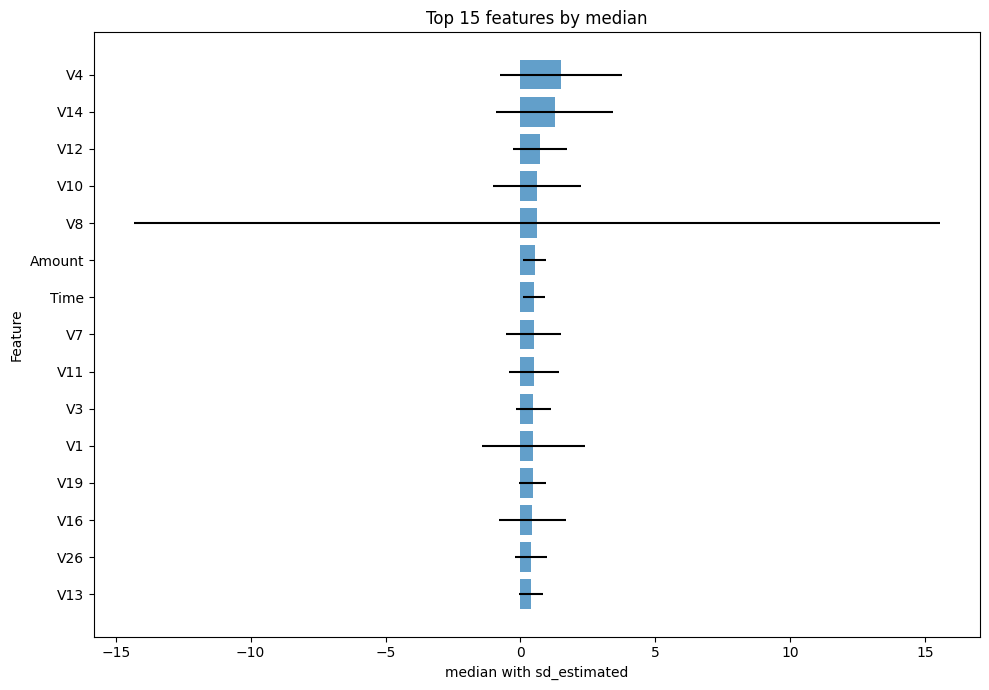

In [32]:
top_with_error = plot_top_feature_with_error(
    xgb_feature_kde,
    top_k=15,
    score_col="median",
)

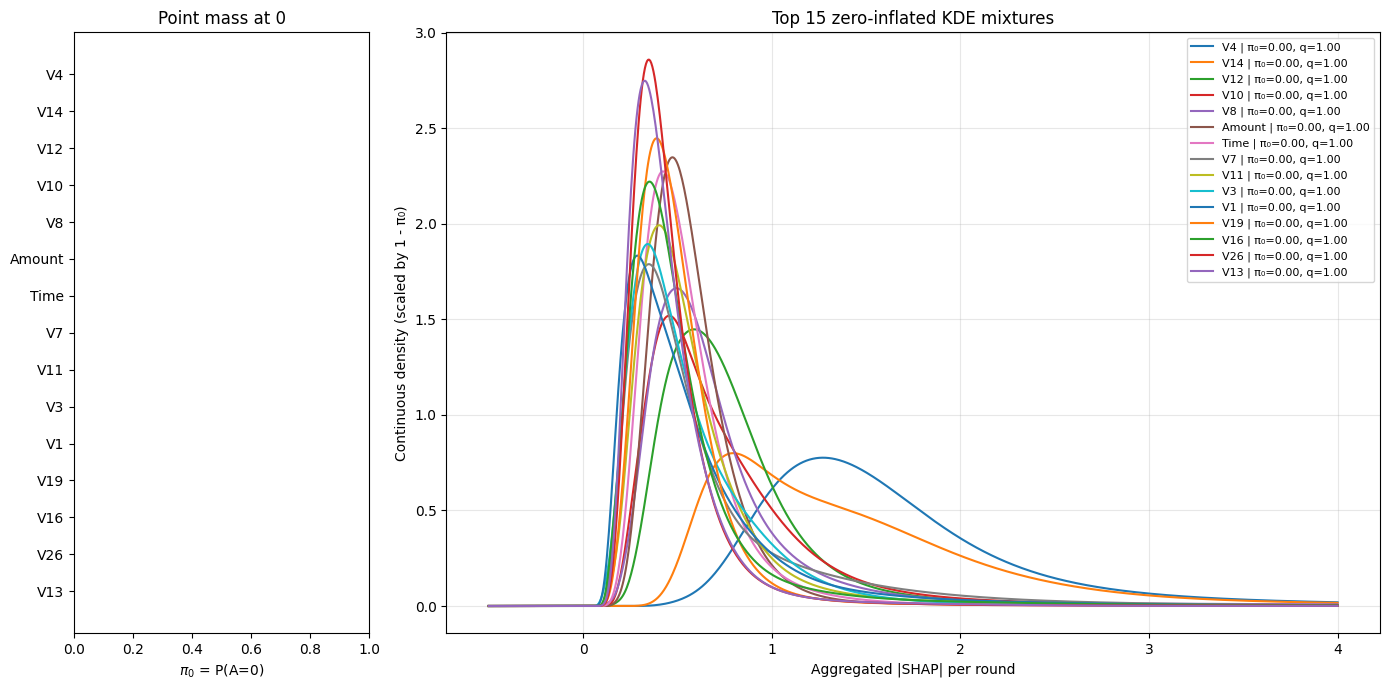

In [40]:
lgb_top = plot_top_feature_density(
    xgb_feature_kde,
    top_k=15,
    score_col="median",
    x_min = -0.5,
    log_x=True,
    x_max=4
)

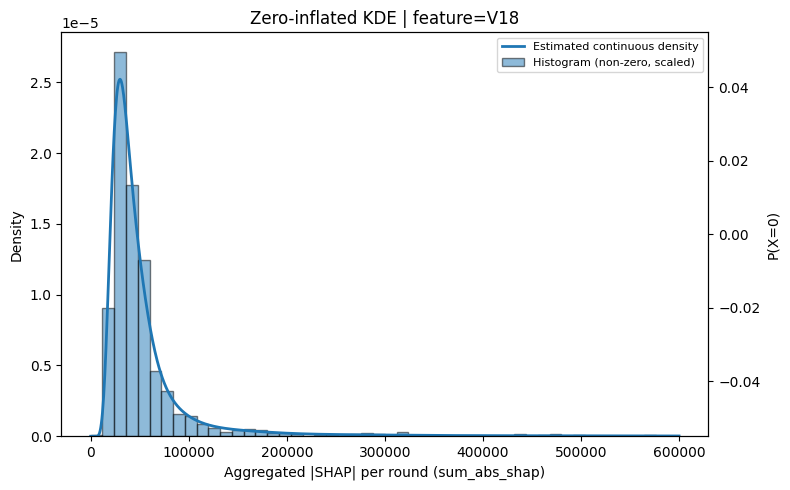

In [64]:
plot_feature_level_kde_with_hist_preagg(
    feature_level_df=xgb_feature_kde,
    boot_results=xgb_boot_results,
    feature="V18",
    bins = 50,
    xlim=(-0.5, 6e5)
)

/tmp/ipykernel_2761183/1466389247.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


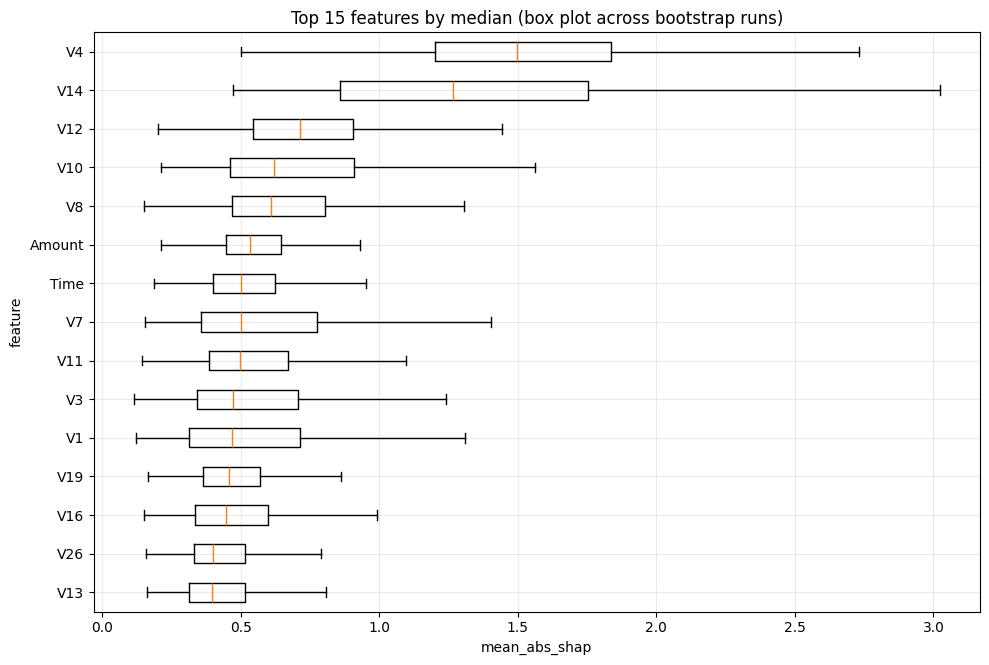

,feature,mean_abs_shap,bootstrap_id
0,Amount,0.448353,0
1,Time,0.724063,0
2,V1,1.700550,0
3,V10,0.738586,0
4,V11,0.354994,0


In [41]:
# Box plot for top features (run-level aggregated SHAP values)
top_k = 15
score_col = "median"   # ranking metric from xgb_feature_kde
agg_col = "mean_abs_shap"      # column in each element of xgb_boot_results

ranked = (
    xgb_feature_kde[["feature", score_col]]
    .dropna(subset=[score_col])
    .sort_values(score_col, ascending=False)
)

top_features = ranked["feature"].astype(str).head(top_k).tolist()

box_rows = []
for b, res in enumerate(xgb_boot_results):
    part = res.loc[:, ["feature", agg_col]].copy()
    part["feature"] = part["feature"].astype(str)
    part = part[part["feature"].isin(top_features)]
    part["bootstrap_id"] = b
    box_rows.append(part)

box_df = pd.concat(box_rows, ignore_index=True)
box_df = box_df.dropna(subset=[agg_col])

plot_data = [box_df.loc[box_df["feature"] == f, agg_col].to_numpy() for f in top_features]

plt.figure(figsize=(10, max(5, 0.45 * len(top_features))))
plt.boxplot(
    plot_data,
    labels=top_features,
    vert=False,
    showfliers=False,
)
plt.xlabel(agg_col)
plt.ylabel("feature")
plt.title(f"Top {len(top_features)} features by {score_col} (box plot across bootstrap runs)")
plt.grid(alpha=0.25)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

box_df.head()

### Feature selection

In [42]:
# statistic you queried
stat = (xgb_feature_kde["mean_estimated"]* xgb_feature_kde["median"]) / xgb_feature_kde["sd_estimated"]
# stat = xgb_feature_kde["nonzero_median"]*xgb_feature_kde["p_nonzero"]
stat = stat.replace([np.inf, -np.inf], np.nan).dropna()


qs = [0.01, 0.05,0.1,0.25, 0.50, 0.75, 0.8, 0.90,0.94, 0.95, 0.96,0.99]
qvals = stat.quantile(qs)
print("Quantiles of the statistic (mean^2 / sd):")
for q, val in zip(qs, qvals):
    print(f"  {q:.2%}: {val:.4f}") 

Quantiles of the statistic (mean^2 / sd):
  1.00%: 0.0174
  5.00%: 0.0784
  10.00%: 0.1629
  25.00%: 0.2397
  50.00%: 0.3327
  75.00%: 0.4323
  80.00%: 0.4534
  90.00%: 0.6944
  94.00%: 0.7881
  95.00%: 0.8395
  96.00%: 0.8909
  99.00%: 1.1213


In [95]:
q = stat.quantile(0.90)
print(f"75th percentile threshold: {q:.4f}")

# Attach statistic to feature table (index-aligned) and filter
tmp = xgb_feature_kde.copy()
tmp["stat"] = stat

features_above_q = (
    tmp.loc[tmp["stat"] > q, ["feature", "stat"]]
       .sort_values("stat", ascending=False)
       .reset_index(drop=True)
)

print(f"Number of features above 75th percentile: {len(features_above_q)}")
display(features_above_q)

# If you only want feature IDs as a Python list:
feature_list_above_q = features_above_q["feature"].astype(str).tolist()
print(feature_list_above_q)

75th percentile threshold: 0.6944
Number of features above 75th percentile: 3


,feature,stat
0,V4,1.203802
1,V14,0.919299
2,Amount,0.742008


['V4', 'V14', 'Amount']


In [96]:
X_xgb = X[feature_list_above_q]

In [97]:
print("Training XGBoost model...")
X_temp, X_xgb_test, y_temp, y_xgb_test = train_test_split(X_xgb, y, test_size=0.2, random_state=11, stratify=y)
X_xgb_train, X_xgb_val, y_xgb_train, y_xgb_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=11, stratify=y_temp)  # 0.25 x 0.8 = 0.2
print(f"Training set: {X_xgb_train.shape}")
print(f"Validation set: {X_xgb_val.shape}")
print(f"Test set: {X_xgb_test.shape}")

dtrain = xgb.DMatrix(X_xgb_train, label=y_xgb_train, enable_categorical=True)
dval   = xgb.DMatrix(X_xgb_val,   label=y_xgb_val,   enable_categorical=True)
dtest  = xgb.DMatrix(X_xgb_test,  label=y_xgb_test,  enable_categorical=True)


Training XGBoost model...
Training set: (170883, 3)
Validation set: (56962, 3)
Test set: (56962, 3)


[0]	train-logloss:0.01175	valid-logloss:0.01202


[10]	train-logloss:0.00544	valid-logloss:0.00709
[20]	train-logloss:0.00416	valid-logloss:0.00616
[30]	train-logloss:0.00318	valid-logloss:0.00562
[40]	train-logloss:0.00278	valid-logloss:0.00540
[50]	train-logloss:0.00265	valid-logloss:0.00554
[60]	train-logloss:0.00259	valid-logloss:0.00564
[70]	train-logloss:0.00254	valid-logloss:0.00576
[80]	train-logloss:0.00252	valid-logloss:0.00586
[90]	train-logloss:0.00249	valid-logloss:0.00598
[100]	train-logloss:0.00248	valid-logloss:0.00609
[110]	train-logloss:0.00247	valid-logloss:0.00629
[120]	train-logloss:0.00245	valid-logloss:0.00637
[130]	train-logloss:0.00245	valid-logloss:0.00648
[140]	train-logloss:0.00244	valid-logloss:0.00656
[150]	train-logloss:0.00243	valid-logloss:0.00669
[160]	train-logloss:0.00244	valid-logloss:0.00683
[170]	train-logloss:0.00242	valid-logloss:0.00698
[180]	train-logloss:0.00243	valid-logloss:0.00709
[190]	train-logloss:0.00243	valid-logloss:0.00725
[199]	train-logloss:0.00242	valid-logloss:0.00734
✓ Model t

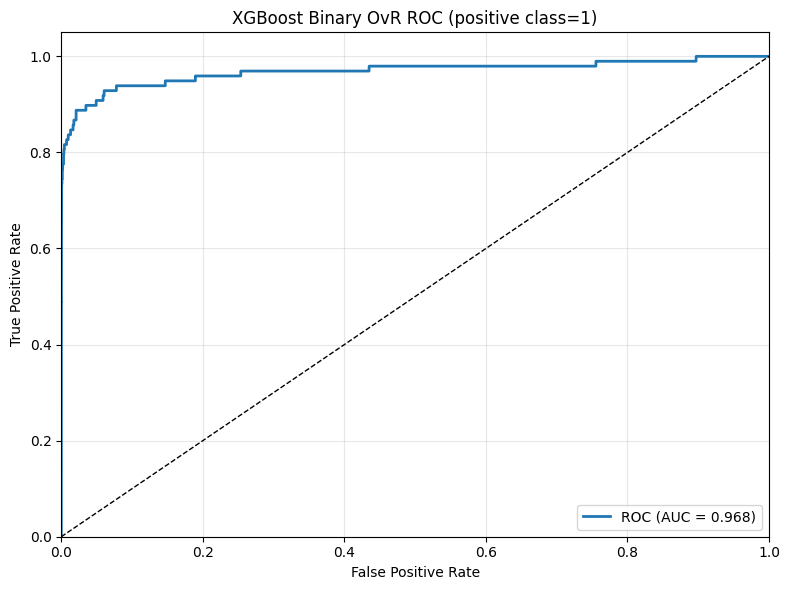

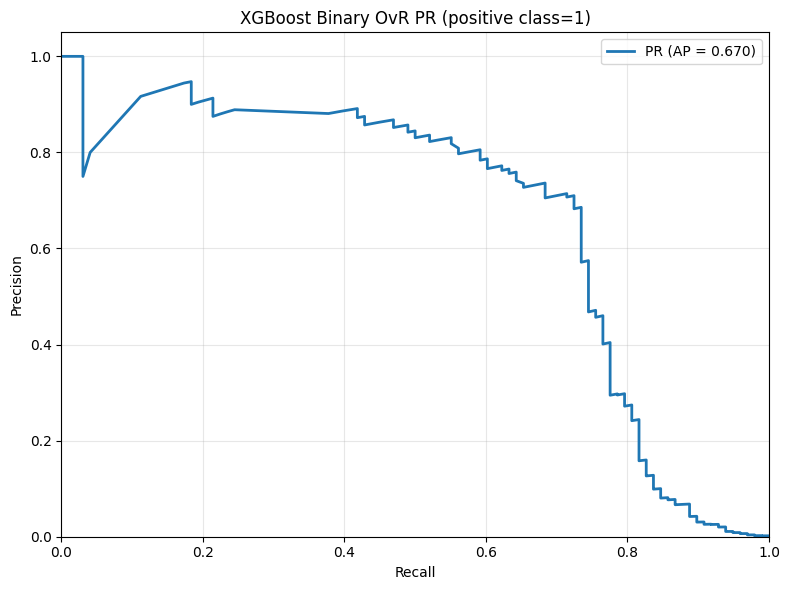


Confusion Matrix (positive class=1):
[[56844    20]
 [   36    62]]

Classification Report (binary OvR):
              precision    recall  f1-score   support

 not class 1       1.00      1.00      1.00     56864
     class 1       0.76      0.63      0.69        98

    accuracy                           1.00     56962
   macro avg       0.88      0.82      0.84     56962
weighted avg       1.00      1.00      1.00     56962



In [98]:
# Train model using best iteration from CV
# print(f"Training with best_iteration from CV: {best_iteration}")
xgb_model = xgb.train(
    binary_params,                      # or xgb_params if you are doing multiclass
    dtrain,
    num_boost_round=200,
    evals=[(dtrain, "train"), (dval, "valid")],
    verbose_eval=10
)

print("✓ Model training complete!")

# Choose positive class for binary one-vs-rest evaluation
positive_class = 1
classes_xgb = np.sort(np.unique(y_xgb_train))
if positive_class not in classes_xgb:
    raise ValueError(f"positive_class={positive_class} not found in labels: {classes_xgb}")

# Predict on test set
# strict_shape=True makes output handling more consistent across objectives
raw_pred = xgb_model.predict(dtest, strict_shape=True)

# Build probability for the positive class from different XGBoost output shapes
raw_pred = np.asarray(raw_pred)

if raw_pred.ndim == 1:
    # Binary objective may return probability of positive class directly
    y_xgb_pred_proba = raw_pred.astype(float)
elif raw_pred.ndim == 2:
    if raw_pred.shape[1] == 1:
        y_xgb_pred_proba = raw_pred[:, 0].astype(float)
    elif raw_pred.shape[1] == 2:
        # Binary output returning [P(class0), P(class1)]
        y_xgb_pred_proba = raw_pred[:, 1].astype(float)
    else:
        # Multiclass output; use OvR probability for selected positive class
        pos_idx = int(np.where(classes_xgb == positive_class)[0][0])
        if pos_idx >= raw_pred.shape[1]:
            raise ValueError(
                f"positive class index {pos_idx} out of bounds for prediction shape {raw_pred.shape}"
            )
        y_xgb_pred_proba = raw_pred[:, pos_idx].astype(float)
elif raw_pred.ndim == 3:
    # strict_shape=True can produce (n_samples, n_groups, n_classes_or_1)
    # for binary: n_classes_or_1 is often 1
    if raw_pred.shape[2] == 1:
        y_xgb_pred_proba = raw_pred[:, 0, 0].astype(float)
    else:
        pos_idx = int(np.where(classes_xgb == positive_class)[0][0])
        if pos_idx >= raw_pred.shape[2]:
            raise ValueError(
                f"positive class index {pos_idx} out of bounds for prediction shape {raw_pred.shape}"
            )
        y_xgb_pred_proba = raw_pred[:, 0, pos_idx].astype(float)
else:
    raise ValueError(f"Unexpected prediction shape: {raw_pred.shape}")

# Binary true labels and predictions (positive class vs rest)
y_test_arr = np.asarray(y_xgb_test)
y_true_bin = (y_test_arr == positive_class).astype(int)
y_pred_bin = (y_xgb_pred_proba >= 0.5).astype(int)

# Accuracy
test_accuracy_xgb = accuracy_score(y_true_bin, y_pred_bin)
print(f"\nTest set accuracy (OvR, class={positive_class}): {test_accuracy_xgb:.4f}")

# F1 scores
f1_binary = f1_score(y_true_bin, y_pred_bin, average="binary")
f1_macro = f1_score(y_true_bin, y_pred_bin, average="macro")
f1_weighted = f1_score(y_true_bin, y_pred_bin, average="weighted")

print("\nF1 Scores (OvR):")
print(f"  Binary (positive class={positive_class}): {f1_binary:.4f}")
print(f"  Macro-average: {f1_macro:.4f}")
print(f"  Weighted-average: {f1_weighted:.4f}")

# Binary ROC AUC and curve
auc_xgb = roc_auc_score(y_true_bin, y_xgb_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_true_bin, y_xgb_pred_proba)
print("\nBinary ROC AUC (OvR):")
print(f"  AUC: {auc_xgb:.4f}")

# Binary AUPRC and curve
precision_xgb, recall_xgb, _ = precision_recall_curve(y_true_bin, y_xgb_pred_proba)
auprc_xgb = average_precision_score(y_true_bin, y_xgb_pred_proba)
print("\nBinary AUPRC (OvR):")
print(f"  AP: {auprc_xgb:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, lw=2, label=f"ROC (AUC = {auc_xgb:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"XGBoost Binary OvR ROC (positive class={positive_class})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, lw=2, label=f"PR (AP = {auprc_xgb:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"XGBoost Binary OvR PR (positive class={positive_class})")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix and classification report (binary labels)
print("\n" + "=" * 50)
print(f"Confusion Matrix (positive class={positive_class}):")
print(confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]))

print("\nClassification Report (binary OvR):")
print(classification_report(
    y_true_bin,
    y_pred_bin,
    labels=[0, 1],
    target_names=[f"not class {positive_class}", f"class {positive_class}"],
))

### Compare with other methods

In [118]:
feature_shap = shap_feature_ranking.iloc[:3]['feature'].tolist()
X_xgb = X[feature_shap]

In [119]:
X_temp, X_xgb_test, y_temp, y_xgb_test = train_test_split(X_xgb, y, test_size=0.2, random_state=11, stratify=y)
X_xgb_train, X_xgb_val, y_xgb_train, y_xgb_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=11, stratify=y_temp)  # 0.25 x 0.8 = 0.2
print(f"Training set: {X_xgb_train.shape}")
print(f"Validation set: {X_xgb_val.shape}")
print(f"Test set: {X_xgb_test.shape}")

dtrain = xgb.DMatrix(X_xgb_train, label=y_xgb_train, enable_categorical=True)
dval   = xgb.DMatrix(X_xgb_val,   label=y_xgb_val,   enable_categorical=True)
dtest  = xgb.DMatrix(X_xgb_test,  label=y_xgb_test,  enable_categorical=True)


Training set: (170883, 3)
Validation set: (56962, 3)
Test set: (56962, 3)


[0]	train-logloss:0.10241	valid-logloss:0.10046


[10]	train-logloss:0.26039	valid-logloss:0.27068
[20]	train-logloss:0.05824	valid-logloss:0.05941
[30]	train-logloss:0.03660	valid-logloss:0.04053
[40]	train-logloss:0.03566	valid-logloss:0.04059
[50]	train-logloss:0.02785	valid-logloss:0.03554
[60]	train-logloss:0.02805	valid-logloss:0.03684
[70]	train-logloss:0.02575	valid-logloss:0.03475
[80]	train-logloss:0.02554	valid-logloss:0.03479
[90]	train-logloss:0.02503	valid-logloss:0.03442
[100]	train-logloss:0.02540	valid-logloss:0.03471
[110]	train-logloss:0.02533	valid-logloss:0.03500
[120]	train-logloss:0.02504	valid-logloss:0.03522
[130]	train-logloss:0.02501	valid-logloss:0.03481
[140]	train-logloss:0.02519	valid-logloss:0.03512
[150]	train-logloss:0.02573	valid-logloss:0.03693
[160]	train-logloss:0.02599	valid-logloss:0.03694
[170]	train-logloss:0.02608	valid-logloss:0.03732
[180]	train-logloss:0.02607	valid-logloss:0.03763
[190]	train-logloss:0.02648	valid-logloss:0.03753
[199]	train-logloss:0.02645	valid-logloss:0.03776
✓ Model t

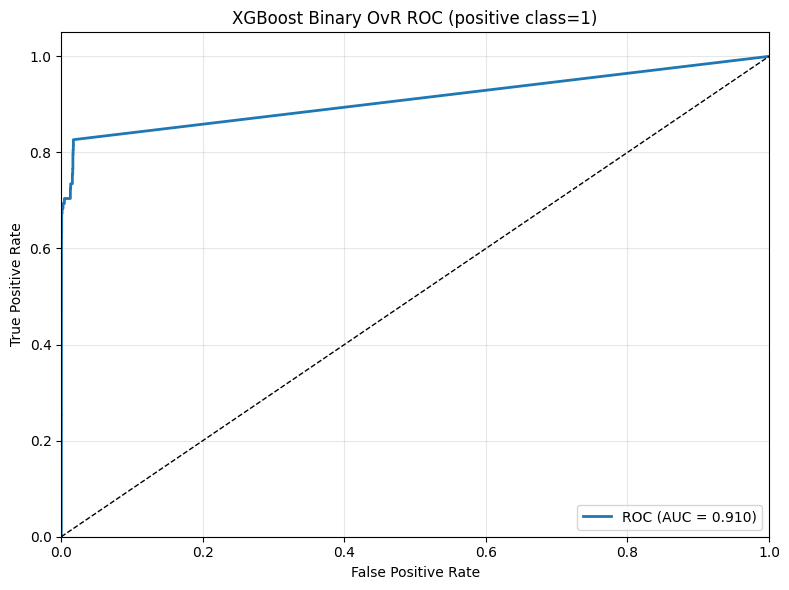

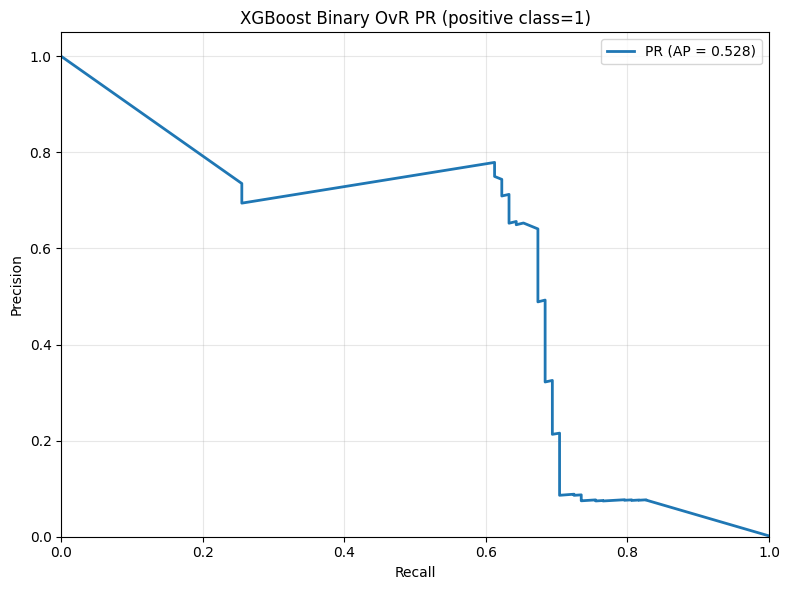


Confusion Matrix (positive class=1):
[[56819    45]
 [   32    66]]

Classification Report (binary OvR):
              precision    recall  f1-score   support

 not class 1       1.00      1.00      1.00     56864
     class 1       0.59      0.67      0.63        98

    accuracy                           1.00     56962
   macro avg       0.80      0.84      0.82     56962
weighted avg       1.00      1.00      1.00     56962



In [120]:
# Train model using best iteration from CV
# print(f"Training with best_iteration from CV: {best_iteration}")
xgb_model = xgb.train(
    binary_params,                      # or xgb_params if you are doing multiclass
    dtrain,
    num_boost_round=200,
    evals=[(dtrain, "train"), (dval, "valid")],
    verbose_eval=10
)

print("✓ Model training complete!")

# Choose positive class for binary one-vs-rest evaluation
positive_class = 1
classes_xgb = np.sort(np.unique(y_xgb_train))
if positive_class not in classes_xgb:
    raise ValueError(f"positive_class={positive_class} not found in labels: {classes_xgb}")

# Predict on test set
# strict_shape=True makes output handling more consistent across objectives
raw_pred = xgb_model.predict(dtest, strict_shape=True)

# Build probability for the positive class from different XGBoost output shapes
raw_pred = np.asarray(raw_pred)

if raw_pred.ndim == 1:
    # Binary objective may return probability of positive class directly
    y_xgb_pred_proba = raw_pred.astype(float)
elif raw_pred.ndim == 2:
    if raw_pred.shape[1] == 1:
        y_xgb_pred_proba = raw_pred[:, 0].astype(float)
    elif raw_pred.shape[1] == 2:
        # Binary output returning [P(class0), P(class1)]
        y_xgb_pred_proba = raw_pred[:, 1].astype(float)
    else:
        # Multiclass output; use OvR probability for selected positive class
        pos_idx = int(np.where(classes_xgb == positive_class)[0][0])
        if pos_idx >= raw_pred.shape[1]:
            raise ValueError(
                f"positive class index {pos_idx} out of bounds for prediction shape {raw_pred.shape}"
            )
        y_xgb_pred_proba = raw_pred[:, pos_idx].astype(float)
elif raw_pred.ndim == 3:
    # strict_shape=True can produce (n_samples, n_groups, n_classes_or_1)
    # for binary: n_classes_or_1 is often 1
    if raw_pred.shape[2] == 1:
        y_xgb_pred_proba = raw_pred[:, 0, 0].astype(float)
    else:
        pos_idx = int(np.where(classes_xgb == positive_class)[0][0])
        if pos_idx >= raw_pred.shape[2]:
            raise ValueError(
                f"positive class index {pos_idx} out of bounds for prediction shape {raw_pred.shape}"
            )
        y_xgb_pred_proba = raw_pred[:, 0, pos_idx].astype(float)
else:
    raise ValueError(f"Unexpected prediction shape: {raw_pred.shape}")

# Binary true labels and predictions (positive class vs rest)
y_test_arr = np.asarray(y_xgb_test)
y_true_bin = (y_test_arr == positive_class).astype(int)
y_pred_bin = (y_xgb_pred_proba >= 0.5).astype(int)

# Accuracy
test_accuracy_xgb = accuracy_score(y_true_bin, y_pred_bin)
print(f"\nTest set accuracy (OvR, class={positive_class}): {test_accuracy_xgb:.4f}")

# F1 scores
f1_binary = f1_score(y_true_bin, y_pred_bin, average="binary")
f1_macro = f1_score(y_true_bin, y_pred_bin, average="macro")
f1_weighted = f1_score(y_true_bin, y_pred_bin, average="weighted")

print("\nF1 Scores (OvR):")
print(f"  Binary (positive class={positive_class}): {f1_binary:.4f}")
print(f"  Macro-average: {f1_macro:.4f}")
print(f"  Weighted-average: {f1_weighted:.4f}")

# Binary ROC AUC and curve
auc_xgb = roc_auc_score(y_true_bin, y_xgb_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_true_bin, y_xgb_pred_proba)
print("\nBinary ROC AUC (OvR):")
print(f"  AUC: {auc_xgb:.4f}")

# Binary AUPRC and curve
precision_xgb, recall_xgb, _ = precision_recall_curve(y_true_bin, y_xgb_pred_proba)
auprc_xgb = average_precision_score(y_true_bin, y_xgb_pred_proba)
print("\nBinary AUPRC (OvR):")
print(f"  AP: {auprc_xgb:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, lw=2, label=f"ROC (AUC = {auc_xgb:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"XGBoost Binary OvR ROC (positive class={positive_class})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, lw=2, label=f"PR (AP = {auprc_xgb:.3f})")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"XGBoost Binary OvR PR (positive class={positive_class})")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Confusion matrix and classification report (binary labels)
print("\n" + "=" * 50)
print(f"Confusion Matrix (positive class={positive_class}):")
print(confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1]))

print("\nClassification Report (binary OvR):")
print(classification_report(
    y_true_bin,
    y_pred_bin,
    labels=[0, 1],
    target_names=[f"not class {positive_class}", f"class {positive_class}"],
))